# Book Recommendation — *"I like Lord of the Rings, what else should I read?"*

**Problem.** Given a single book the user likes — only a **title**, with no user history — recommend other books they are likely to enjoy. This is an **item-seeded** task (the seed is a *book*), not personalised user-history recommendation.

![Recommendation pipeline](img/reco_pipeline_new.svg)
<!--<img src="img/reco_pipeline.svg" width="800"> -->

**Data.** The Book-Crossing dataset, cleaned and enriched in the companion notebook (`Data_Analysis_Book_Recommendation.ipynb`): ~50k books and ~284k explicit ratings (1–10), with per-book metadata pulled from _OpenLibrary_ (`Year`, `Subjects`, `Publisher`, `Language`).

**Approach.** A bare title gives no user profile, so classic user-to-item collaborative filtering doesn't apply directly. We bridge to the item-seeded task **two ways**:
- **Item-to-item similarity** — books close to the query by *co-rating patterns* (Item-CF) or by *content* (TF-IDF [Term Frequency-Inverse Document Frequency] on title/author/subjects).
- **Fan-based collaborative filtering (CF)** — find the query book's **fans** (users who rated it highly), predict how they would rate every other book, and recommend the highest — wrapping SVD (Singular Value Decomposition), User-CF, and a gradient-boosted model.

The methods are combined into a hybrid model by **RRF** (Reciprocal Rank Fusion).

**Methods:** 
- Item-based CF (cosine KNN) 
- Content-based (TF-IDF) 
- SVD latent factors
- User-based CF (mean-centered-cosine KNN [k-Nearest Neighbors])  
- LightGBM (feature-based) 
- Hybrid  

**Language scoping.** Models train on the **full multilingual catalogue** (maximum collaborative signal), but the *recommendations* are filtered to a chosen language set (**English by default**) — so, e.g., a German edition of *Lord of the Rings* is never returned for an English query.

![Filters pipeline](img/filters_pipeline.svg)
<!--<img src="img/reco_pipeline.svg" width="800"> -->


In [1]:
import re  # regex: only used by filter_same_work's normalize_author() to strip
          # non-letters from author names so spellings compare equal (de-dup same works) 
import numpy as np
np.set_printoptions(legacy="1.21")
import pandas as pd
#import seaborn as sns
from scipy.sparse import csr_matrix # Compressed Sparse Row. For fast row slicing, faster matrix vector products
from sklearn.feature_extraction.text import TfidfVectorizer # Convert text data into numerical features
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

import ast # ast.literal_eval to safely evaluate string representations of lists

# Load the data

In [2]:
# loading data
input_path = "cleaned_data/"
books = pd.read_csv(input_path + "Books.csv", dtype={"Year": "Int32", "TotalRating": "Int32"})
#users = pd.read_csv(input_path + "Users.csv", dtype={"User-ID": "Int32"})
ratings = pd.read_csv(input_path + "Ratings.csv", dtype={"Rating": "Int32"})

# -- Check shapes --
print("Books:", books.shape)
print("Ratings:", ratings.shape)
print("Top five languages:", books["Language"].value_counts(normalize=True).head(5))

Books: (50389, 8)
Ratings: (284351, 3)
Top five languages: Language
English    0.889599
German     0.036059
Spanish    0.019290
unknown    0.018893
French     0.018575
Name: proportion, dtype: float64


In [3]:
books.TotalRating.describe()

count     50389.0
mean     5.643117
std      12.37769
min           2.0
25%           2.0
50%           3.0
75%           5.0
max         707.0
Name: TotalRating, dtype: Float64

In [4]:
# Relative cumulative rating = mean rating per book (sum of ratings / number of ratings).
# Ranges 1-10; a quality signal independent of popularity (unlike TotalRating, the count).
rating_sum = ratings.groupby('ISBN')['Rating'].sum()
books['Rel_Cum_Rating'] = (books['ISBN'].map(rating_sum) / books['TotalRating']).round(2)
books = books[['ISBN', 'Title', 'Author', 'Year', 'Publisher','Subjects', 'Language', 'TotalRating', 'Rel_Cum_Rating']]
books.Rel_Cum_Rating.describe()

count     50389.0
mean     7.585127
std       1.20198
min           1.0
25%           7.0
50%          7.67
75%           8.5
max          10.0
Name: Rel_Cum_Rating, dtype: Float64

In [5]:
books.sort_values('TotalRating', ascending=False).head(10)

,ISBN,Title,Author,Year,Publisher,Subjects,Language,TotalRating,Rel_Cum_Rating
292,0316666343,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown","['Murder', 'Psychological fiction']",English,707,8.19
11,0971880107,Wild Animus,Rich Shapero,2004,Too Far,"['Fiction', 'Spiritual life']",English,581,4.39
525,0385504209,The Da Vinci Code,Dan Brown,2003,Doubleday,"['Suspense & Thriller', 'Spiritual Fiction']",English,487,8.44
359,0312195516,The Red Tent (Bestselling Backlist),Anita Diamant,1998,Picador USA,"['Women in the Bible', 'Fiction']",English,383,8.18
771,0060928336,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,1997,Perennial,"['Fiction', 'Literature']",English,320,7.89
1480,059035342X,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,1999,Arthur A. Levine Books,"['series:Harry_Potter', 'Ghosts']",English,313,8.94
258,0142001740,The Secret Life of Bees,Sue Monk Kidd,2003,Penguin Books,"['Teenage girls', 'Fiction']",English,307,8.45
497,0446672211,Where the Heart Is (Oprah's Book Club (Paperba...,Billie Letts,1998,Warner Books,"['Fiction', 'Friendship']",English,295,8.14
220,044023722X,A Painted House,John Grisham,2001,Dell Publishing Company,"['Boys', 'Cotton farmers']",English,281,7.34
162,0452282152,Girl with a Pearl Earring,Tracy Chevalier,2001,Plume Books,"[""Artists' models"", ""Artists' models in fiction""]",English,278,7.98


#  Contruction of basic matrices and functions
### Rating Matrix Construction
Build the user-item rating matrix used by collaborative filtering methods.

In [6]:
# --- Build SPARSE user-item matrix (instead of pivotting) ---
# Encode UserID and ISBN to integer indices for matrix construction
isbn_enc = {isbn: i for i, isbn in enumerate(ratings['ISBN'].unique())} # encode ISBN to index
user_enc = {uid: i for i, uid in enumerate(ratings['UserID'].unique())} # encode UserID to index
isbn_dec = {i: isbn for isbn, i in isbn_enc.items()} # decodes for ISBN
user_dec = {i: uid for uid, i in user_enc.items()} # decodes mapping for UserID

n_users = len(user_enc)
n_items = len(isbn_enc)

rows = ratings['UserID'].map(user_enc).to_numpy()
cols = ratings['ISBN'].map(isbn_enc).to_numpy()
vals = ratings['Rating'].to_numpy().astype(np.float32)

# CSR: efficient for row (user) operations; CSC: efficient for column (item) operations
user_item_sparse = csr_matrix((vals, (rows, cols)), shape=(n_users, n_items)) #rating matrix
# Equivalent to a users vs. books pivot matrix
print(f"Sparse user-item matrix: {user_item_sparse.shape}, nnz={user_item_sparse.nnz}")
print(f"Memory: {user_item_sparse.data.nbytes / 1e6:.1f} MB (vs ~{n_users * n_items * 4 / 1e9:.1f} GB dense)")

Sparse user-item matrix: (59163, 50389), nnz=284351
Memory: 1.1 MB (vs ~11.9 GB dense)


### TF-IDF matrix

In [7]:
# --- Build content features ---
def parse_subjects(s):
    """Parse the Subjects column (stored as string repr of a list)."""
    if pd.isna(s):
        return ''
    try:
        items = ast.literal_eval(s) 
        if isinstance(items, list):
            return ' '.join(items)
    except (ValueError, SyntaxError):
        pass
    return str(s)

books_content = books.copy()
books_content['SubjectsText'] = books_content['Subjects'].apply(parse_subjects)
# Repeat subjects 3x so TF-IDF weights them more than title/author
books_content['Content'] = (
    books_content['Title'].fillna('') + ' ' +
    books_content['Author'].fillna('') + ' ' +
    books_content['Publisher'].fillna('') + ' ' +
    books_content['Year'].astype(str).fillna('') + ' ' +
    (books_content['SubjectsText'] + ' ') * 3
)

# Term Frequency-Inverse Document Frequency with bigrams (two consecutive words) for richer matching lie "Lord Rings" or "Science Fiction"
tfidf = TfidfVectorizer(min_df=2, # at least two books sharing a term. Minimum contribution to book-to-book similarity
                        max_features=30000, # max. number of terms
                        ngram_range=(1, 2), # unigrams an bigrams
                        stop_words='english') # removes common words like "the", "a", "of", "and", "in" etc.
tfidf_matrix = tfidf.fit_transform(books_content['Content'])
print(f"TF-IDF matrix: {tfidf_matrix.shape}")

content_isbn_list = books_content['ISBN'].tolist()
content_isbn_to_idx = {isbn: i for i, isbn in enumerate(content_isbn_list)}

TF-IDF matrix: (50389, 30000)


In [8]:
# --- Global recommendation defaults (single source of truth for all 6 models) ---
N_RECS = 10               # default number of recommendations each model returns
MIN_REL_CUM_RATING = 7    # min mean rating (1-10) a book needs to appear in results

isbn_to_author = books.set_index('ISBN')['Author'].to_dict()

# --- Helper lookups ---

def find_isbns_by_title(query, books_df=books):
    """Return all ISBNs whose title contains `query` (case-insensitive)."""
    mask = books_df['Title'].str.contains(query, case=False, na=False)
    return set(books_df.loc[mask, 'ISBN'])

# --- Quick check ---
lotr_isbns = find_isbns_by_title("Lord of the Rings")
print(f"LoTR editions found: {len(lotr_isbns)}")


# --- Language scoping for recommendation OUTPUT (models still train on ALL languages) ---
DEFAULT_LANGUAGES = {"English"}   # what every *_recommend returns unless `languages` is given

def allowed_isbns(books_df, min_ratings, languages=None):
    """ISBNs eligible to be RECOMMENDED: enough ratings AND in an allowed language.

    languages:
        None  -> DEFAULT_LANGUAGES (English)
        a name / list / set, e.g. "Spanish" or {"English", "German"}
        "all" -> disable the language filter (recommend in any language)
    """
    mask = books_df["TotalRating"] >= min_ratings
    if languages != "all":
        if languages is None:
            langs = set(DEFAULT_LANGUAGES)
        elif isinstance(languages, str):
            langs = {languages}
        else:
            langs = set(languages)
        mask &= books_df["Language"].isin(langs)
    return set(books_df.loc[mask, "ISBN"])

def filter_same_work(result_df, title_query, sim_threshold=0.26):
    """Remove books that are likely the same work (same author + high content similarity)."""
    query_isbns = find_isbns_by_title(title_query, books_content)
    query_idxs = [content_isbn_to_idx[isbn] for isbn in query_isbns if isbn in content_isbn_to_idx]
    if not query_idxs or result_df.empty:
        return result_df

    def normalize_author(name):
        return re.sub(r'[^a-z]', '', name.lower()) # removes both the space and the apostrophe

    query_authors = {normalize_author(isbn_to_author.get(isbn, '')) for isbn in query_isbns}
    query_vec = np.asarray(tfidf_matrix[query_idxs].mean(axis=0)) #mean vector 

    drop_isbns = set()
    for _, row in result_df.iterrows():
        isbn = row['ISBN']
        author = row.get('Author', '')
        if normalize_author(author) not in query_authors: 
            continue
        if isbn in content_isbn_to_idx:
            sim = cosine_similarity(query_vec, tfidf_matrix[content_isbn_to_idx[isbn]]).flatten()[0]
            if sim > sim_threshold:
                drop_isbns.add(isbn)

    filtered = result_df[~result_df['ISBN'].isin(drop_isbns)].reset_index(drop=True)
    if len(drop_isbns) > 0:
        print(f"  Filtered {len(drop_isbns)} same-work duplicates (same author + content sim > {sim_threshold})")
    return filtered

def cap_per_family(result_df, max_per_family=2, content_threshold=0.5, title_threshold=0.3):
    """Diversify a ranked result list by capping near-identical 'families' (e.g. the
    whole Harry Potter series) to their top `max_per_family` rows by score.

    A family = SAME author AND (high TF-IDF content similarity OR strong title-token
    overlap). So a *series* (HP1..HP7, near-identical appeal) collapses, while an
    author's *distinct* works (e.g. The Hobbit vs The Silmarillion) survive.
    Assumes result_df is already sorted best-first. Tune the two thresholds with the
    'HP must collapse to 2, the 3 Tolkien works must stay' test.
    """
    if result_df.empty:
        return result_df

    def _author(n):
        return re.sub(r'[^a-z]', '', str(n).lower())
    _stop = {'the', 'and', 'of', 'a', 'an', 'or', 'book', 'novel', 'vol', 'volume',
             'part', 'series', 'paperback', 'edition', 'chronicles'}
    def _title_toks(t):
        return {w for w in re.findall(r'[a-z]+', str(t).lower()) if len(w) > 2 and w not in _stop}

    kept_idx, anchors, counts = [], [], {}   # anchors: (author, content_idx, title_toks, family_rep)
    for idx, row in result_df.iterrows():
        a = _author(row.get('Author', ''))
        ci = content_isbn_to_idx.get(row['ISBN'])
        tt = _title_toks(row.get('Title', ''))
        rep = None
        for (a2, ci2, tt2, rep2) in anchors:
            if not a or a2 != a:                 # different (or missing) author -> different family
                continue
            csim = 0.0
            if ci is not None and ci2 is not None:
                csim = cosine_similarity(tfidf_matrix[ci], tfidf_matrix[ci2]).flatten()[0]
            tsim = len(tt & tt2) / len(tt | tt2) if (tt or tt2) else 0.0
            if csim > content_threshold or tsim > title_threshold:
                rep = rep2
                break
        if rep is None:                          # start a new family
            kept_idx.append(idx); counts[row['ISBN']] = 1
            anchors.append((a, ci, tt, row['ISBN']))
        elif counts[rep] < max_per_family:       # family still has room
            kept_idx.append(idx); counts[rep] += 1
            anchors.append((a, ci, tt, rep))
        # else: family already full -> drop this row

    dropped = len(result_df) - len(kept_idx)
    if dropped > 0:
        print(f"  cap_per_family: dropped {dropped} rows exceeding {max_per_family}/family")
    return result_df.loc[kept_idx].reset_index(drop=True)

LoTR editions found: 66


# Item-to-item approach
## Method 1: Item-Based Collaborative Filtering (KNN)

**Idea**: Find similar _items_ (books) — two books are similar if they were rated by the *same users*, and those shared users gave them *similar ratings*. We use cosine similarity on the sparse *item-user* vectors.

**Two robustness fixes for sparse / multi-edition queries:**

1. **Edition pooling.** A work like *The Lord of the Rings* has 66 separate ISBNs (in our dataset), 44 of them with ≤5 raters. Querying each edition and taking the *max* similarity let an obscure edition (4 raters) inject spurious matches. Instead we **pool all editions into one work-level vector** (each user counted once); with 551 distinct LotR raters a candidate must overlap with *many* of them, so 2-user flukes vanish. Result: the pooled query returns Harry Potter and *The Hobbit*.

2. **Significance weighting (shrinkage).** Cosine is unreliable when two books share few raters. We multiply each similarity by $\min(\text{shared raters},\,C)/C$ (default $C=10$), shrinking matches backed by only a handful of users toward zero. This hardens single-edition queries too.

A large **candidate pool** is pulled before the `min_ratings` filter so a full top-N survives.

In [9]:
# Fit KNN on the raw item-user sparse matrix (items as rows, users as columns)
item_user_sparse = user_item_sparse.T.tocsr()  # shape: (items, n_users)
knn_model = NearestNeighbors(metric='cosine', algorithm='brute') 
knn_model.fit(item_user_sparse) # model fits on books in rating space
print(f"KNN model fitted on {item_user_sparse.shape[0]} items x {item_user_sparse.shape[1]} users")

KNN model fitted on 50389 items x 59163 users


In [10]:
def item_based_cf(title_query, books_df=books, n_recs=N_RECS, min_ratings=10,
                  candidate_pool=200, shrinkage=10, min_rcr=MIN_REL_CUM_RATING, languages=None):
    """
    Item-Based CF using KNN (cosine) on the raw item-user sparse matrix.

    - Edition pooling: all editions of the queried work are merged into one
      work-level vector (each user counted once) before a single KNN query,
      which removes the spurious matches that low-support editions otherwise
      inject via the max-similarity merge.
    - Significance weighting: each similarity is scaled by
      min(shared_raters, shrinkage) / shrinkage, down-weighting matches backed
      by only a few shared users. Set shrinkage=0 to disable.
    """
    query_isbns = find_isbns_by_title(title_query, books_df)
    query_idxs = [isbn_enc[isbn] for isbn in query_isbns if isbn in isbn_enc]
    if not query_idxs:
        print(f"No books found matching '{title_query}' in the rating matrix")
        return pd.DataFrame()

    # Pool all editions into one work-level vector (binary: each user counts once)
    pooled = np.asarray((item_user_sparse[query_idxs] > 0).sum(axis=0)).flatten() # indexed by user
    pooled = (pooled > 0).astype(np.float64) #if True -> 1, False -> 0; binary component
    #pooled is a vector in user-space but it represents the query book.
    n_raters = int(pooled.sum())
    print(f"Item-CF '{title_query}': pooled {len(query_idxs)} editions "
          f"-> {n_raters} distinct raters (shrinkage C={shrinkage})")
    pooled_sp = csr_matrix(pooled.reshape(1, -1)) # (n_users,) vector -> (1, n_users) matrix

    # Single KNN query on the pooled vector; pull a large pool before filtering
    n_req = min(item_user_sparse.shape[0], candidate_pool + len(query_idxs))
    distances, indices = knn_model.kneighbors(pooled_sp, n_neighbors=n_req) # nearer books

    query_set = set(query_idxs)
    candidates = {}  # isbn -> (possibly shrunk) similarity
    for dist, neighbor_idx in zip(distances.flatten(), indices.flatten()):
        if neighbor_idx in query_set:
            continue
        isbn = isbn_dec[neighbor_idx]
        sim = 1 - dist  # cosine distance -> similarity
        if shrinkage: # Shrinkage fixes the candidate side 
            # how many of this candidate's raters are also raters of the query work
            shared = pooled[item_user_sparse[neighbor_idx].indices].sum()
            sim *= min(shared, shrinkage) / shrinkage
        if isbn not in candidates or sim > candidates[isbn]:
            candidates[isbn] = sim

    # Filter to books with enough ratings, then take top-N
    valid_isbns = allowed_isbns(books_df, min_ratings, languages)
    candidates = {isbn: s for isbn, s in candidates.items() if isbn in valid_isbns}
    top = sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:n_recs]

    result = pd.DataFrame(top, columns=['ISBN', 'Score'])
    result = result.merge(books_df[['ISBN', 'Title', 'Author', 'TotalRating', 'Subjects','Rel_Cum_Rating']], on='ISBN')
    result = result[result['Rel_Cum_Rating'] >= min_rcr]  # display-only: keep books with mean rating >= min_rcr
    result = result[['ISBN', 'Title', 'Score', 'Author','Subjects', 'TotalRating', 'Rel_Cum_Rating']]
    # Score = similarity
    return filter_same_work(result, title_query)

In [11]:
# Test Method 1
print("=" * 100)
print("METHOD 1: Item-Based Collaborative Filtering")
print("=" * 100)
recs_item_cf = item_based_cf("Lord of the Rings")
recs_item_cf

METHOD 1: Item-Based Collaborative Filtering
Item-CF 'Lord of the Rings': pooled 66 editions -> 551 distinct raters (shrinkage C=10)


,ISBN,Title,Score,Author,Subjects,TotalRating,Rel_Cum_Rating
0,0439064864,Harry Potter and the Chamber of Secrets (Book 2),0.148842,J. K. Rowling,"['series:Harry_Potter', 'Fantasy fiction']",126,8.92
1,043935806X,Harry Potter and the Order of the Phoenix (Boo...,0.137512,J. K. Rowling,"[""Children's Books/Ages 9-12 Fiction"", 'Witche...",206,9.03
2,0618002219,The Hobbit: or There and Back Again,0.125678,J.R.R. Tolkien,"['Fantasy', 'Arkenstone']",39,9.0
3,0439139597,Harry Potter and the Goblet of Fire (Book 4),0.121533,J. K. Rowling,"['orphans', 'foster homes']",137,9.26
4,0590353403,Harry Potter and the Sorcerer's Stone (Book 1),0.118013,J. K. Rowling,"['series:Harry_Potter', 'Ghosts']",119,8.98
5,059035342X,Harry Potter and the Sorcerer's Stone (Harry P...,0.102136,J. K. Rowling,"['series:Harry_Potter', 'Ghosts']",313,8.94
6,0439064872,Harry Potter and the Chamber of Secrets (Book 2),0.094295,J. K. Rowling,"['series:Harry_Potter', 'Fantasy fiction']",189,8.78
7,0345325818,The Silmarillion,0.093110,J.R.R. TOLKIEN,"['Fantasy fiction', 'Short stories']",30,8.33
8,0064471047,"The Lion, the Witch, and the Wardrobe (The Chr...",0.092070,C. S. Lewis,"['the Blitz', 'fauns']",42,8.71
9,0441172717,Dune (Remembering Tomorrow),0.088282,Frank Herbert,"['Dune (Imaginary place)', 'Fiction']",75,8.97


# Method 2: Content-Based Filtering (TF-IDF)

**Idea**: Represent each book as a text document combining its Title, Author, Publisher, Year and Subjects. Use TF-IDF to vectorize, then recommend books with the highest cosine similarity to the queried book's content profile.

In [12]:
def content_based(title_query, n_recs=N_RECS, min_ratings=5, min_rcr=MIN_REL_CUM_RATING, languages=None):
    """
    Content-Based: TF-IDF cosine similarity on Title + Author + Subjects.
    
    Averages the TF-IDF vectors of all editions matching the query to form
    a single query profile, then finds the most similar books.
    """
    query_isbns = find_isbns_by_title(title_query, books_content)
    query_idxs = [content_isbn_to_idx[isbn] for isbn in query_isbns if isbn in content_isbn_to_idx]
    
    if not query_idxs:
        print(f"No books found matching '{title_query}'")
        return pd.DataFrame()
    
    print(f"Content query: {len(query_idxs)} editions")
    
    # Average TF-IDF vector across all query editions (convert from matrix to array)
    query_vec = np.asarray(tfidf_matrix[query_idxs].mean(axis=0)) #average over items (books); vector of features
    
    sims = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    scored = pd.Series(sims, index=content_isbn_list) # content_isbn_list = books_content['ISBN'].tolist()
    # removes the queried book's own editions from the results
    scored = scored.drop(labels=list(query_isbns), errors='ignore')
    
    valid_isbns = allowed_isbns(books_content, min_ratings, languages)
    scored = scored[scored.index.isin(valid_isbns)]
    
    top = scored.sort_values(ascending=False).head(n_recs * 3)
    
    result = pd.DataFrame({
        'ISBN': top.index,
        'Score': top.values
    }).reset_index(drop=True)
    result = result.merge(
        books_content[['ISBN', 'Title', 'Author', 'TotalRating', 'Subjects', 'Rel_Cum_Rating']], on='ISBN'
    )
    result = result[result['Rel_Cum_Rating'] >= min_rcr]  # display-only: keep books with mean rating >= min_rcr
    result = result[['ISBN', 'Title', 'Score', 'Author', 'Subjects', 'TotalRating', 'Rel_Cum_Rating']]
    result = filter_same_work(result, title_query)
    return result.head(n_recs)

In [13]:
# Test Method 2
print("=" * 100)
print("METHOD 2: Content-Based Filtering (TF-IDF)")
print("=" * 100)
recs_content = content_based("Lord of the Rings")
recs_content

METHOD 2: Content-Based Filtering (TF-IDF)
Content query: 66 editions
  Filtered 5 same-work duplicates (same author + content sim > 0.26)


,ISBN,Title,Score,Author,Subjects,TotalRating,Rel_Cum_Rating
0,0345357116,Unfinished Tales: The Lost Lore of Middle-earth,0.159544,J. R. R. Tolkien,"['English Fantasy fiction', 'Middle Earth (Ima...",7,7.43
1,0380776162,Lord of Scoundrels,0.156737,Loretta Chase,NaN,6,9.0
2,0395257301,The Silmarillion,0.156486,J. R. R. Tolkien,"['Fantasy fiction', 'Short stories']",8,7.0
3,0395071224,The Hobbit,0.156163,J. R. R. Tolkien,"['Fantasy', 'Arkenstone']",6,9.67
4,0812563190,Elvenblood (Halfblood Chronicles),0.155297,Andre Norton,"['Elves', 'Fiction']",9,7.78
5,0618002219,The Hobbit: or There and Back Again,0.155180,J.R.R. Tolkien,"['Fantasy', 'Arkenstone']",39,9.0
6,0812511751,The Elvenbane (Halfblood Chronicles),0.149168,Andre Norton,"['Elves', 'Fiction']",12,7.58
7,0812522400,Lord of the Isles (Lord of the Isles),0.146165,David Drake,"['Fantasy fiction', 'Fiction, fantasy, epic']",10,7.3
8,034537522X,The Book of Lost Tales 2 (The History of Middl...,0.140183,J.R.R. TOLKIEN,"['Tolkien', 'Middle-Earth']",6,7.67
9,0345375211,The Book of Lost Tales 1 (The History of Middl...,0.139412,J. R. R. Tolkien,"['Tolkien', 'Middle-Earth']",12,7.33


# Fan-based approach
## Method 3: Latent Factor Model (Truncated SVD)

**Idea**: Decompose the mean-centered user-item rating matrix (for removing user rating bias) via truncated SVD into latent factors:

$$R - \mu \;\approx\; U \,\Sigma \,V^T$$

Each user becomes a row of $U\Sigma$ and each item a column of $V^T$ in a shared $k$-dimensional space. To predict a rating:

$$\hat{r}(u,i) = \bar{r}_u + (U \Sigma)_u \cdot V^T_i$$

**Recommendation strategy — fan-based prediction**: Given a query title, find its *fans* (users who rated it highly), reconstruct their predicted ratings for all items via the formula above, and recommend the items with the highest average predicted rating across fans.

> **Note**: The latent factors capture **collaborative** structure — books that tend to be rated similarly by the same users end up nearby in the embedding space. This finds items with similar *rating patterns*, not necessarily similar *content* (that's what Method 4: Content-Based does).

In [14]:
from scipy.sparse.linalg import svds

# --- Mean-center the sparse rating matrix(subtract each user's mean from rated entries) ---
user_sums = np.asarray(user_item_sparse.sum(axis=1)).flatten() # sum of ratings for each user
user_nnz = np.asarray((user_item_sparse > 0).sum(axis=1)).flatten() # number of rated books per user
# clip(min=1) insures we don't divide by zero for users with no ratings
user_means = user_sums / user_nnz # mu in the above formula

rows_nz, cols_nz = user_item_sparse.nonzero() # indices of non-zero elements
centered_data = user_item_sparse.data.astype(np.float64) - user_means[rows_nz]
user_item_centered = csr_matrix((centered_data, (rows_nz, cols_nz)), shape=user_item_sparse.shape)

### Hyperparameter Tuning: Optimal K (latent factors) for SVD

`K_FACTORS` above was picked off the scree plot (singular-value magnitude), not by
predictive accuracy. Here we choose it the same way as the other methods: held-out
**RMSE** on the 80/20 per-user split, reusing `evaluate_K` / `evaluate_item_K`'s split.

We also report a **\"predict the user's mean\" baseline** (effectively K=0). Plain
truncated SVD centres the observed entries and leaves every unobserved cell at 0,
so the low-rank fit is pulled toward each user's mean. If SVD's RMSE barely beats
this baseline, that mean-regression is confirmed — and since `svd_recommend` only
*ranks* items, also watch whether a better RMSE actually changes the ranking.

/tmp/ipykernel_144515/2799383249.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_ratings = ratings.groupby('UserID', group_keys=False).apply(


K=  10  →  RMSE=1.6501  coverage=100.0%
K=  20  →  RMSE=1.6498  coverage=100.0%
K=  30  →  RMSE=1.6498  coverage=100.0%
K=  40  →  RMSE=1.6495  coverage=100.0%
K=  50  →  RMSE=1.6494  coverage=100.0%
K=  60  →  RMSE=1.6494  coverage=100.0%
K=  70  →  RMSE=1.6493  coverage=100.0%
K=  80  →  RMSE=1.6493  coverage=100.0%
K=  90  →  RMSE=1.6492  coverage=100.0%
K= 100  →  RMSE=1.6491  coverage=100.0%
K= 110  →  RMSE=1.6490  coverage=100.0%
K= 120  →  RMSE=1.6490  coverage=100.0%
K= 130  →  RMSE=1.6489  coverage=100.0%
K= 140  →  RMSE=1.6488  coverage=100.0%
K= 150  →  RMSE=1.6488  coverage=100.0%
K= 160  →  RMSE=1.6487  coverage=100.0%
K= 170  →  RMSE=1.6487  coverage=100.0%
K= 180  →  RMSE=1.6487  coverage=100.0%
K= 190  →  RMSE=1.6489  coverage=100.0%
K= 200  →  RMSE=1.6489  coverage=100.0%

Baseline (predict user mean) RMSE = 1.6503
Best K (latent factors): 160  (RMSE=1.6487, improvement over baseline = +0.0017)


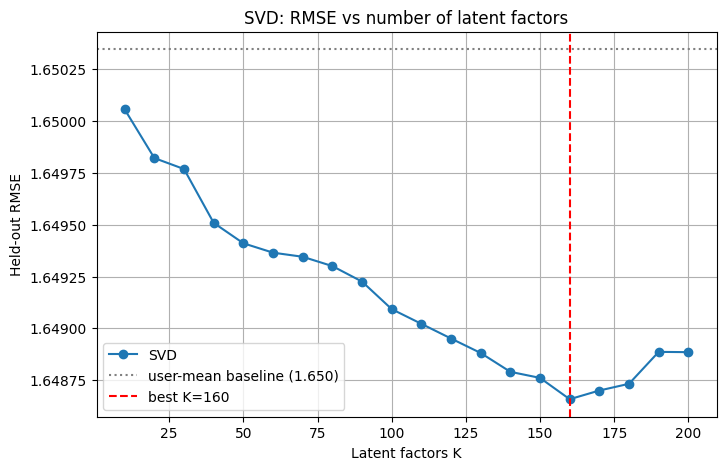

In [16]:
if 'train_sparse' not in globals():
    train_ratings = ratings.groupby('UserID', group_keys=False).apply(
        lambda x: x.sample(frac=0.8, random_state=42))
    test_ratings = ratings.drop(train_ratings.index)
    train_user_enc = {uid: i for i, uid in enumerate(train_ratings['UserID'].unique())}
    train_isbn_enc = {isbn: i for i, isbn in enumerate(train_ratings['ISBN'].unique())}
    tr = train_ratings['UserID'].map(train_user_enc).to_numpy()
    tc = train_ratings['ISBN'].map(train_isbn_enc).to_numpy()
    tv = train_ratings['Rating'].to_numpy().astype(np.float32)
    train_sparse = csr_matrix((tv, (tr, tc)),
                              shape=(len(train_user_enc), len(train_isbn_enc)))

# --- Centre the TRAIN matrix on each user's mean (observed entries only) ---
_u_sums = np.asarray(train_sparse.sum(axis=1)).flatten()
_u_nnz  = np.asarray((train_sparse > 0).sum(axis=1)).flatten().clip(min=1)
svd_user_means = _u_sums / _u_nnz
_r, _c = train_sparse.nonzero()
_centered = train_sparse.data.astype(np.float64) - svd_user_means[_r]
train_centered = csr_matrix((_centered, (_r, _c)), shape=train_sparse.shape)

# --- Factorize ONCE at the largest K; a smaller K is just the top-k of these factors ---
K_svd_values = [k_svd_tem for k_svd_tem in range(10, 205,10)]
U_full, sigma_full, Vt_full = svds(train_centered, k=max(K_svd_values))  # ascending order


def evaluate_svd_K(K):
    """Held-out RMSE for an SVD with K latent factors.
    pred(u,i) = user_mean[u] + (U*sigma)_u . Vt_i, over test pairs whose user AND
    item were seen in training. Coverage = predictable fraction (≈100%: SVD can
    score any seen user/item pair, unlike the neighbour-gated KNN methods)."""
    U, s, Vt = U_full[:, -K:], sigma_full[-K:], Vt_full[-K:, :]
    US = U * s

    test_valid = test_ratings[
        test_ratings['UserID'].isin(train_user_enc) &
        test_ratings['ISBN'].isin(train_isbn_enc)
    ].copy()
    if test_valid.empty:
        return np.nan, 0.0

    # Score the FULL 20% test set (seen user+item). SVD prediction is a cheap
    # embedding dot product, so the 200-user cap the KNN sweeps need is unnecessary.
    errors = []
    for uid, grp in test_valid.groupby('UserID'):
        u = train_user_enc[uid]
        pred_row = svd_user_means[u] + US[u] @ Vt    # predicted ratings for ALL items
        for isbn, actual in zip(grp['ISBN'], grp['Rating']):
            errors.append((pred_row[train_isbn_enc[isbn]] - actual) ** 2)

    coverage = len(errors) / len(test_valid) if len(test_valid) else 0.0
    return (np.sqrt(np.mean(errors)) if errors else np.nan), coverage


results_svd_K, coverage_svd_K = {}, {}
for K in K_svd_values:
    rmse, cov = evaluate_svd_K(K)
    results_svd_K[K] = rmse
    coverage_svd_K[K] = cov
    print(f"K={K:4d}  →  RMSE={rmse:.4f}  coverage={cov*100:5.1f}%")

# --- Baseline: predict each user's own mean (the K=0 limit) ---
_base = test_ratings[test_ratings['UserID'].isin(train_user_enc) &
                     test_ratings['ISBN'].isin(train_isbn_enc)].copy()
_umean = {uid: svd_user_means[i] for uid, i in train_user_enc.items()}
_base['pred'] = _base['UserID'].map(_umean)
base_rmse = np.sqrt(((_base['pred'] - _base['Rating']) ** 2).mean())

best_svd_K = min((K for K in results_svd_K if not np.isnan(results_svd_K[K])),
                 key=lambda K: results_svd_K[K])
print(f"\nBaseline (predict user mean) RMSE = {base_rmse:.4f}")
print(f"Best K (latent factors): {best_svd_K}  (RMSE={results_svd_K[best_svd_K]:.4f}, "
      f"improvement over baseline = {base_rmse - results_svd_K[best_svd_K]:+.4f})")
plt.figure(figsize=(8, 5))
plt.plot(list(results_svd_K.keys()), list(results_svd_K.values()), 'o-', label='SVD')
plt.axhline(base_rmse, color='gray', ls=':', label=f'user-mean baseline ({base_rmse:.3f})')
plt.axvline(best_svd_K, color='red', ls='--', label=f'best K={best_svd_K}')
plt.xlabel('Latent factors K')
plt.ylabel('Held-out RMSE')
plt.title('SVD: RMSE vs number of latent factors')
plt.grid(True); plt.legend(); plt.show()

SVD: k=160, U_sigma shape=(59163, 160), Vt shape=(160, 50389)
Top singular values: [148.3  67.7  53.   47.   45.7  44.2  43.3  42.9  40.8  40.1]


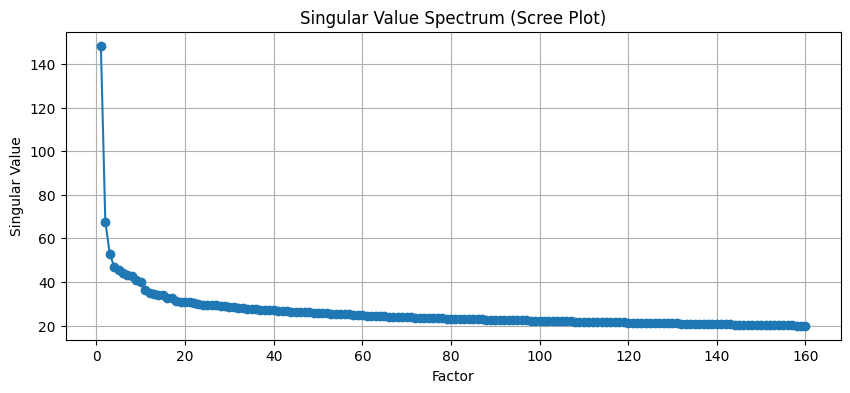

In [17]:
# --- Truncated SVD ---
K_FACTORS = best_svd_K 
U, sigma, Vt = svds(user_item_centered.astype(np.float64), k=K_FACTORS)

# User embeddings: U * Sigma — used for rating prediction r_hat(u,i) = mean_u + (U*Sigma)_u @ Vt_i
U_sigma = U * sigma  # shape: (n_users, k)

print(f"SVD: k={K_FACTORS}, U_sigma shape={U_sigma.shape}, Vt shape={Vt.shape}")
print(f"Top singular values: {sigma[-10:][::-1].round(1)}")
plt.figure(figsize=(10, 4))
plt.plot(range(1, K_FACTORS + 1), sigma[::-1], 'o-')
plt.xlabel('Factor')
plt.ylabel('Singular Value')
plt.title('Singular Value Spectrum (Scree Plot)')
plt.grid(True)
#plt.plot(range(1, K_FACTORS), np.diff(sigma[::-1]), 'o-')
plt.show()
# With K_FACTORS = 20 we capture the dominant structure plus a few extra factors 

In [18]:
def svd_recommend(title_query, books_df=books, ratings_df=ratings,
                  n_recs=N_RECS, fan_threshold=8, min_ratings=5, min_rcr=MIN_REL_CUM_RATING, languages=None):
    """
    SVD fan-based recommendation: reconstruct predicted ratings for fans of the query book,
    then recommend items with the highest average predicted rating.
    The ratings considered for fan_thresholdare as follows, 
    10: The Best
    9-8: Amazing (Outstanding, highly impressive)
    7-6: Good (Solid, reliable, above average)
    5-4: OK (Average, passable, needs minor improvements)
    3-2: Bad (Significantly flawed, problematic)
    1: Worst (Complete failure, unacceptable)
    """
    query_isbns = find_isbns_by_title(title_query, books_df)
    if not query_isbns:
        print(f"No books found matching '{title_query}'")
        return pd.DataFrame()

    # Find fans: users who rated any edition of the query book >= fan_threshold
    fan_ratings = ratings_df[ratings_df['ISBN'].isin(query_isbns)]
    fans = fan_ratings[fan_ratings['Rating'] >= fan_threshold]['UserID'].unique()
    fan_indices = [user_enc[uid] for uid in fans if uid in user_enc]

    if len(fan_indices) < 2:
        print(f"Not enough fans for '{title_query}' (found {len(fan_indices)})")
        return pd.DataFrame()

    print(f"SVD query: '{title_query}' → {len(fan_indices)} fans (rated >= {fan_threshold})")

    # Predicted rating for user u, item i: r_hat(u,i) = mean_u + (U*Sigma)_u @ Vt_i
    # Average across fans (linearity lets us average embeddings first):
    # avg_pred_i = mean(mean_u for fans) + mean((U*Sigma)_u for fans) @ Vt_i
    avg_fan_mean = user_means[fan_indices].mean()
    avg_fan_embedding = U_sigma[fan_indices].mean(axis=0)  # shape: (k,)
    avg_pred = avg_fan_mean + avg_fan_embedding @ Vt  # shape: (n_items,)

    # Exclude query book editions
    query_idxs = {isbn_enc[isbn] for isbn in query_isbns if isbn in isbn_enc}
    for idx in query_idxs:
        avg_pred[idx] = -np.inf

    # Filter to books with enough ratings
    valid_isbns = allowed_isbns(books_df, min_ratings, languages)

    scored = {}
    for idx in np.argsort(-avg_pred):
        isbn = isbn_dec.get(idx)
        if isbn is None or isbn in query_isbns:
            continue
        if isbn not in valid_isbns:
            continue
        scored[isbn] = avg_pred[idx]
        if len(scored) >= n_recs:
            break

    result = pd.DataFrame({
        'ISBN': list(scored.keys()),
        'PredictedRating': list(scored.values())
    }).reset_index(drop=True)
    result = result.merge(books_df[['ISBN', 'Title', 'Author', 'TotalRating', 'Subjects', 'Rel_Cum_Rating']], on='ISBN')
    result = result[result['Rel_Cum_Rating'] >= min_rcr]  # display-only: keep books with mean rating >= min_rcr
    result = result[['ISBN', 'Title', 'PredictedRating', 'Author', 'Subjects', 'TotalRating', 'Rel_Cum_Rating']]
    return filter_same_work(result, title_query)

In [19]:
# Test Method 3
print("=" * 100)
print("METHOD 3: SVD Latent Factor (Fan-Based Prediction)")
print("=" * 100)
recs_svd = svd_recommend("Lord of the Rings")
recs_svd

METHOD 3: SVD Latent Factor (Fan-Based Prediction)
SVD query: 'Lord of the Rings' → 468 fans (rated >= 8)


,ISBN,Title,PredictedRating,Author,Subjects,TotalRating,Rel_Cum_Rating
0,059035342X,Harry Potter and the Sorcerer's Stone (Harry P...,8.471444,J. K. Rowling,"['series:Harry_Potter', 'Ghosts']",313,8.94
1,0439139597,Harry Potter and the Goblet of Fire (Book 4),8.471108,J. K. Rowling,"['orphans', 'foster homes']",137,9.26
2,0439064864,Harry Potter and the Chamber of Secrets (Book 2),8.465209,J. K. Rowling,"['series:Harry_Potter', 'Fantasy fiction']",126,8.92
3,043935806X,Harry Potter and the Order of the Phoenix (Boo...,8.459164,J. K. Rowling,"[""Children's Books/Ages 9-12 Fiction"", 'Witche...",206,9.03
4,0446310786,To Kill a Mockingbird,8.452305,Harper Lee,"['fiction', 'fiction classics']",214,8.94
5,0345313860,"The Vampire Lestat (Vampire Chronicles, Book II)",8.448980,ANNE RICE,"['nobility', 'vampire novels']",143,7.95
6,0385504209,The Da Vinci Code,8.447996,Dan Brown,"['Suspense & Thriller', 'Spiritual Fiction']",487,8.44
7,0439136369,Harry Potter and the Prisoner of Azkaban (Book 3),8.443692,J. K. Rowling,"['Fantasy fiction', 'orphans']",133,9.08
8,0590353403,Harry Potter and the Sorcerer's Stone (Book 1),8.443405,J. K. Rowling,"['series:Harry_Potter', 'Ghosts']",119,8.98
9,0441003257,Good Omens,8.440980,Neil Gaiman,"['End of the world', 'Humorous']",87,8.2


## Method 4: User-Based Collaborative Filtering (KNNWithMeans + mean-centered cosine)

**Idea**: Find users who loved the queried book (*fans*), then for **each individual fan** find their K nearest neighbors using mean-centered cosine similarity (≈ Pearson). Predict ratings via the KNNWithMeans formula and average predictions across all fans.

- **Per-fan neighbors** (not a single virtual profile) preserve the diversity of fan tastes — a LotR fan who reads sci-fi and one who reads literary fiction contribute different neighbor pools.
- **Mean-centered cosine** removes user bias (lenient vs. strict raters).

In [20]:
def user_based_cf(title_query, ratings_df=ratings, books_df=books,
                  n_recs=N_RECS, fan_threshold=8, min_ratings=10, K=18, min_rcr=MIN_REL_CUM_RATING, languages=None):
    """
    User-Based CF: per-fan KNN with KNNWithMeans prediction.

    1. Find fans (users who rated the queried title >= fan_threshold).
    2. Fit KNN (cosine on mean-centered data ≈ Pearson) on all users.
    3. For each fan, find K nearest neighbors and predict ratings
       for items those neighbors rated.
    4. Average raw predictions across fans .
    """
    exclude_isbns = find_isbns_by_title(title_query, books_df)
    if not exclude_isbns:
        print(f"No books found matching '{title_query}'")
        return pd.DataFrame()

    fan_ratings = ratings_df[ratings_df['ISBN'].isin(exclude_isbns)]
    fans = fan_ratings[fan_ratings['Rating'] >= fan_threshold]['UserID'].unique()
    fan_indices = [user_enc[uid] for uid in fans if uid in user_enc]

    if len(fan_indices) < 2:
        print("Not enough fans for similarity computation.")
        return pd.DataFrame()

    print(f"Fans of '{title_query}' (rated >= {fan_threshold}): {len(fan_indices)}")

    # Mean-center all users' ratings (cosine on centered data)
    u_sums = np.asarray(user_item_sparse.sum(axis=1)).flatten()
    u_counts = np.asarray((user_item_sparse > 0).sum(axis=1)).flatten()
    u_means = u_sums / u_counts #average rating per user

    r_nz, c_nz = user_item_sparse.nonzero()
    centered_vals = user_item_sparse.data.astype(np.float64) - u_means[r_nz]
    user_item_centered = csr_matrix(
        (centered_vals, (r_nz, c_nz)), shape=user_item_sparse.shape
    )

    # Fit KNN on all users, query for each fan individually
    knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=K + 1)
    knn.fit(user_item_centered)

    # Batch query: one row per fan
    fan_centered = user_item_centered[fan_indices]
    distances, indices = knn.kneighbors(fan_centered)  # (n_fans, K+1)

    # For each fan, predict ratings via their own neighbors
    fan_item_preds = {}  # isbn -> list of per-fan predictions

    for fan_i, fan_idx in enumerate(fan_indices):
        fan_mean = u_means[fan_idx]

        # Collect this fan's valid neighbors (skip self)
        neighbors = []
        for j in range(distances.shape[1]):
            n_idx = indices[fan_i, j]
            if n_idx == fan_idx:
                continue
            sim = 1 - distances[fan_i, j]
            if sim <= 0:
                continue
            neighbors.append((n_idx, sim))

        if not neighbors:
            continue

        # KNNWithMeans: pred(i) = mean_fan + Σ[sim * (r(v,i) - mean_v)] / Σ[sim]
        item_wdev = {}   # item_idx -> weighted deviation sum
        item_simsum = {} # item_idx -> similarity sum
        # calculation for all neighbors of each fan
        for n_idx, sim in neighbors:
            n_vec = np.asarray(user_item_sparse[n_idx].todense()).flatten()
            rated = np.where(n_vec > 0)[0] # rated items by neighbors.
            if len(rated) == 0:
                continue
            n_mean = n_vec[rated].mean()
            for item_idx in rated:
                dev = n_vec[item_idx] - n_mean
                item_wdev[item_idx] = item_wdev.get(item_idx, 0.0) + sim * dev
                item_simsum[item_idx] = item_simsum.get(item_idx, 0.0) + sim

        # Raw prediction
        for item_idx, wdev in item_wdev.items():
            if item_simsum[item_idx] <= 0:
                continue
            isbn = isbn_dec.get(item_idx)
            if isbn is None or isbn in exclude_isbns:
                continue
            pred = fan_mean + wdev / item_simsum[item_idx]
            if isbn not in fan_item_preds:
                fan_item_preds[isbn] = []
            fan_item_preds[isbn].append(pred) #predicted rating per item for a fan

    # Average predictions across fans
    scores = {isbn: np.mean(preds) for isbn, preds in fan_item_preds.items()}

    valid_isbns = allowed_isbns(books_df, min_ratings, languages)
    scored = pd.Series({isbn: s for isbn, s in scores.items() if isbn in valid_isbns})
    scored = scored.sort_values(ascending=False).head(n_recs)

    result = pd.DataFrame({
        'ISBN': scored.index,
        'CFScore': scored.values
    }).reset_index(drop=True)
    result = result.merge(books_df[['ISBN', 'Title', 'Author', 'TotalRating', 'Subjects', 'Rel_Cum_Rating']], on='ISBN')
    result = result[result['Rel_Cum_Rating'] >= min_rcr]  # display-only: keep books with mean rating >= min_rcr
    result = result[['ISBN', 'Title', 'CFScore', 'Author', 'Subjects', 'TotalRating', 'Rel_Cum_Rating']]
    return filter_same_work(result, title_query)

In [21]:
# Test Method 4
print("=" * 100)
print("METHOD 4: User-Based Collaborative Filtering (mean-centered cosine)")
print("=" * 100)
recs_user_cf = user_based_cf("Lord of the Rings")
recs_user_cf#.sort_values('TotalRating', ascending=False)

METHOD 4: User-Based Collaborative Filtering (mean-centered cosine)
Fans of 'Lord of the Rings' (rated >= 8): 468


,ISBN,Title,CFScore,Author,Subjects,TotalRating,Rel_Cum_Rating
0,0380973545,Letters from a Nut,12.731825,Ted L. Nancy,"['Letters', 'Humor']",29,7.52
1,0385335679,Kissing in Manhattan,12.666667,DAVID SCHICKLER,"['Fiction', 'Fiction, romance, contemporary']",11,8.36
2,0373250290,Carrie Pilby (Red Dress Ink (Paperback)),12.666667,Caren Lissner,"['Young women', 'Fiction']",16,7.69
3,0394574745,"All the Pretty Horses (Border Trilogy, Vol 1)",12.403175,Cormac McCarthy,"['Fiction', 'Ranch life']",11,8.09
4,0345351959,Willow: A Novel,12.126667,Wayland Drew (Adapter),"['Movies', 'Motion Pictures']",10,7.0
5,0449242072,Last Enchantment,12.126667,Moser Mark Stewart,"['Fiction', 'Merlin (Legendary character)']",10,7.9
6,0375725601,"The Devil in the White City: Murder, Magic, an...",12.036993,Erik Larson,"['Social life and customs', 'Murder']",16,8.0
7,0140274154,On the Road (Essential.penguin S.),11.972043,Jack Kerouac,"['Beat generation', 'Fiction']",11,7.55
8,0684824892,Wait Till Next Year : A MEMOIR,11.875000,Doris Kearns Goodwin,"['Brooklyn Dodgers (Baseball team)', 'Biography']",10,7.6
9,0140345353,The Devil's Arithmetic,11.847518,Jane Yolen,"['Fiction', 'Concentration camps']",21,7.95


# Method 5: LightGBM (Feature-Based Learning Model)

The dataset has **no timestamps**, so sequential/temporal recommenders don't apply. A **gradient-boosted tree** predicts the rating of each `(user, item)` pair from engineered features:
- user activity (rating count) and user mean rating,
- the **SVD latent factors** of the user ($U\Sigma$) and item ($V^T$) + the SVD predicted rating.

**Item popularity / mean are deliberately excluded** — with them, the model just predicts ≈ item mean and the top-N collapses to globally popular books for every query (the rating-vs-ranking trap).

Hyperparameters are **tuned once with `RandomizedSearchCV`** (next cell). This model is then (a) used as a standalone recommender, (b) added as a 5th signal to the **Method 6 hybrid**, and (c) fed into the **stacker**.

**Serving (`lightgbm_recommend`)** uses a **prototype-fan** trick: it takes the query book's *fans* (users who rated it ≥ `fan_threshold`), averages them into a single centroid in feature space, and runs **one** LightGBM prediction over all candidate books. Because the features are SVD-derived (and average linearly), this mirrors `svd_recommend`'s averaged-embedding approach and is ~`n_fans`× faster than scoring each fan separately — at the cost of being an approximation of the exact per-fan average.

> **Caveat**: SVD features come from the full matrix, so the standalone val/CV RMSE is mildly optimistic. The leakage-free number is in the Method Comparison (train-only features).

In [22]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, reciprocal

# --- Feature engineering: SVD latent factors + light user stats (NO item popularity) ---
lgb_u_cnt = np.asarray((user_item_sparse > 0).sum(axis=1)).flatten() #user count

def lgb_features(user_idxs, item_idxs):
    """Feature rows for paired (user_idx, item_idx). Item popularity excluded on purpose."""
    # Why SVD factors, not the raw rating row: a raw user row is ~50k cols and ~all zeros
    # (useless for trees, no item-similarity notion). The k=80 SVD factors are compact, dense
    # and similarity-aware. svd_pred is the ready-made collaborative prediction (user.item dot
    # product); the raw U_sigma / Vt let the trees learn nonlinear corrections on top.
    uu = np.asarray(user_idxs); ii = np.asarray(item_idxs)
    svd_pred = user_means[uu] + np.einsum('ij,ji->i', U_sigma[uu], Vt[:, ii])
    base = np.column_stack([
                            lgb_u_cnt[uu],    # User rating count (how many books did this user rate?)
                            user_means[uu],   # User's average rating (is this user a lenient or strict rater?)
                            svd_pred          # SVD's predicted rating for this (user, item) pair
                        ])
    # each row is (user, item) pair, so a user who rated 50 books produces 50 rows, and so on.
    return np.hstack([base, U_sigma[uu], Vt[:, ii].T]) 
    

_ru = ratings['UserID'].map(user_enc).to_numpy()
_ri = ratings['ISBN'].map(isbn_enc).to_numpy()
_ry = ratings['Rating'].to_numpy().astype(float)
X_lgb = lgb_features(_ru, _ri)
print(f"LightGBM feature matrix: {X_lgb.shape}")
rng_lgb = np.random.RandomState(42)
_samp = rng_lgb.choice(len(_ry), size=min(80000, len(_ry)), replace=False)
print('Number of samples:', len(_samp)) # cca 35% of all data
# 284351 = len(_ru), 323 = 3 (from base) + 160 (from U_sigma[uu]) and 160 (from Vt[:, ii].T)

LightGBM feature matrix: (284351, 323)
Number of samples: 80000


In [23]:
# --- Hyperparameter search (run once). Searched on a representative subsample for speed; ---
# --- the winning params are refit on the full data in the next cell.                     ---
lgb_param_dist = {
    'n_estimators':      randint(300, 1500),
    'num_leaves':        randint(15, 128),
    'learning_rate':     reciprocal(0.01, 0.3),
    'subsample':         uniform(0.5, 0.5),    # row sampling 0.5..1.0
    'colsample_bytree':  uniform(0.5, 0.5),    # feature sampling 0.5..1.0
    'reg_alpha':         uniform(0, 10),       # L1
    'reg_lambda':        uniform(0, 10),       # L2
    'min_child_samples': randint(10, 100),
}
lgb_search = RandomizedSearchCV(
                    lgb.LGBMRegressor(objective='regression', 
                        subsample_freq=1,
                        n_jobs=3, 
                        random_state=42, 
                        verbose=-1),
                    param_distributions=lgb_param_dist, 
                    n_iter=50, # combination of hyerparameters
                    cv=5, # cross-validation folds
                    scoring='neg_root_mean_squared_error', 
                    random_state=42,
                    n_jobs=3, 
                    verbose=1)
lgb_search.fit(X_lgb[_samp], _ry[_samp])
lgb_best_params = lgb_search.best_params_
print(f"Best CV RMSE = {-lgb_search.best_score_:.4f}")
print("Best params:", lgb_best_params)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV RMSE = 0.6412
Best params: {'colsample_bytree': 0.8974056517708242, 'learning_rate': 0.05526573288655769, 'min_child_samples': 37, 'n_estimators': 1178, 'num_leaves': 78, 'reg_alpha': 8.64167565071903, 'reg_lambda': 2.3018526824155527, 'subsample': 0.7495966899423762}


In [24]:
# --- Train the final LightGBM on ALL data with the tuned parameters ---
lgb_model = lgb.LGBMRegressor(objective='regression', subsample_freq=1,
                              n_jobs=-1, random_state=42, verbose=-1, **lgb_best_params)
lgb_model.fit(X_lgb, _ry)
print(f"Final LightGBM trained on all {len(_ry)} ratings "
      f"(tuned CV RMSE \u2248 {-lgb_search.best_score_:.3f}).")

Final LightGBM trained on all 284351 ratings (tuned CV RMSE ≈ 0.641).


In [25]:
# Saving the model
import joblib, os, json as _json

# --- Save the best model immediately (sklearn estimator -> joblib) + the tuned params ---
os.makedirs('models', exist_ok=True)
joblib.dump(lgb_model, 'models/lgbm_recommender.pkl')
with open('models/lgbm_best_params.json', 'w') as _f:
    _json.dump(lgb_best_params, _f, indent=2) # pretty-printing

# --- Bundle everything lightgbm_recommend needs in a FRESH session ---
_artifacts = {
    'U_sigma': U_sigma, 'Vt': Vt, 'user_means': user_means, 'lgb_u_cnt': lgb_u_cnt,
    'user_enc': user_enc, 'isbn_enc': isbn_enc, 'isbn_dec': isbn_dec,
    'tfidf_matrix': tfidf_matrix, 'content_isbn_to_idx': content_isbn_to_idx,
    'isbn_to_author': isbn_to_author,
}
joblib.dump(_artifacts, 'models/lgbm_artifacts.joblib', compress=3) # light-to-moderate compression
print('Saved model + params + inference bundle into models/')
# Fresh-session loading is shown in the last cell of the notebook.

Saved model + params + inference bundle into models/


In [26]:
def lightgbm_recommend(title_query, books_df=books, n_recs=N_RECS,
                       fan_threshold=8, min_ratings=3, max_fans=100, min_rcr=MIN_REL_CUM_RATING, languages=None):
    """
    Title-based recommendation via the trained LightGBM, returning the top-N.

    Prototype-fan trick (for speed): instead of predicting for every fan and
    averaging (cost ~ n_fans x n_cand), we average the fans into ONE centroid in
    feature space and predict a single time. LightGBM's inputs are SVD-derived
    (which average linearly), so this mirrors svd_recommend's avg-embedding
    approach -- an approximation of the per-fan average that is ~n_fans times
    faster. `max_fans` therefore now affects only centroid quality, not runtime.
    """
    q = find_isbns_by_title(title_query, books_df)
    fans = ratings[(ratings['ISBN'].isin(q)) & (ratings['Rating'] >= fan_threshold)]['UserID'].unique()
    fan_idx = [user_enc[u] for u in fans if u in user_enc]
    if len(fan_idx) < 2:
        print(f"Not enough fans for '{title_query}'")
        return pd.DataFrame()
    if len(fan_idx) > max_fans:
        fan_idx = list(rng_lgb.choice(fan_idx, max_fans, replace=False))
    print(f"LightGBM '{title_query}': single predict for the centroid of {len(fan_idx)} fans")
    # candidate books
    cand = np.array([isbn_enc[i] for i in allowed_isbns(books_df, min_ratings, languages)
                     if i in isbn_enc])
    # Prototype fan: average the fans' features into one centroid, then predict ONCE.
    cnt_avg  = lgb_u_cnt[fan_idx].mean()                       # avg rating count
    mean_avg = user_means[fan_idx].mean()                      # avg mean rating
    emb_avg  = U_sigma[fan_idx].mean(axis=0)                   # centroid SVD embedding (k,)
    svd_pred = mean_avg + emb_avg @ Vt[:, cand]                # SVD predicted rating per candidate
    base = np.column_stack([np.full(len(cand), cnt_avg), # Returns a new array of given shape and type, filled with fill_value.
                            np.full(len(cand), mean_avg), svd_pred])
    feats = np.hstack([base, np.tile(emb_avg, (len(cand), 1)), Vt[:, cand].T]) # Tile: Construct an array by repeating A the number of times given by reps.
    acc = lgb_model.predict(feats)                             # one batched predict over all candidates

    qset = set(q); rows = []
    for o in np.argsort(-acc):
        isbn = isbn_dec[cand[o]]
        if isbn in qset: #drop books from the query
            continue
        rows.append((isbn, acc[o]))
        if len(rows) >= n_recs * 3:
            break
    res = pd.DataFrame(rows, columns=['ISBN', 'PredictedRating']).merge(
        books_df[['ISBN', 'Title', 'Author', 'TotalRating', 'Subjects', 'Rel_Cum_Rating']], on='ISBN')
    res = res[res['Rel_Cum_Rating'] >= min_rcr]  # display-only: keep books with mean rating >= min_rcr
    res = res[['ISBN', 'Title', 'PredictedRating', 'Author', 'Subjects', 'TotalRating', 'Rel_Cum_Rating']]
    return filter_same_work(res, title_query).head(n_recs)

In [27]:
# Test Method 5
print("=" * 100)
print("METHOD 5: LightGBM (Feature-Based Model)")
print("=" * 100)
lightgbm_recommend("Lord of the Rings")

METHOD 5: LightGBM (Feature-Based Model)
LightGBM 'Lord of the Rings': single predict for the centroid of 100 fans


,ISBN,Title,PredictedRating,Author,Subjects,TotalRating,Rel_Cum_Rating
0,0553213652,The Bhagavad-Gita : Krishna's Counsel in Time ...,10.372964,BARBARA MILLER,"['Hinduism', 'Sacred books']",3,9.33
1,0553211927,Sons and Lovers (Bantam Classics),10.183791,D. H. Lawrence,"['Fiction', 'England in fiction']",4,9.0
2,0312863551,The Moon Is a Harsh Mistress,10.116113,Robert A. Heinlein,"['Fiction, science fiction, general', 'Stone, ...",10,8.5
3,0440153166,Looking for Rachel Wallace,10.100233,ROBERT PARKER,"['Private investigators', 'Spenser (Fictitious...",5,8.6
4,0808514121,East of Eden (Penguin Twentieth-Century Classics),10.078555,John Steinbeck,"['migrant labor', 'historical fiction']",5,8.8
5,0671542036,Halloween Party,10.062583,Agatha Christie,"['Fiction', 'Mystery']",3,8.67
6,0486299929,Six Characters in Search of an Author (Dover T...,9.986967,Luigi Pirandello,"['Drama', 'Characters and characteristics in l...",4,8.5
7,0679601686,Pride and Prejudice (Modern Library),9.926584,JANE AUSTEN,"['Fiction, Romance, Historical, Regency', 'Bri...",5,9.6
8,0394724550,Gift from the sea,9.914488,Anne Morrow Lindbergh,"['Life', 'Ontology']",6,8.0
9,0452271169,Roommates from Hell: True Tales from the Torme...,9.887046,Michelle Weathers,"['Roommates', 'Humor']",3,8.0


# Method 6: Hybrid Recommender (Reciprocal Rank Fusion)

**Why not a weighted score blend?** The four methods produce almost **disjoint** candidate lists (they measure different things), and their raw scores live on incompatible scales (SVD ≈ 8, User-CF ≈ 12, Item-CF ≈ 1, Content ≈ 0.2). A weighted sum of normalized scores then just interleaves four separate lists — every pick comes from a single method, and the result is dominated by whichever method has the largest weight.

**Reciprocal Rank Fusion (RRF)** fixes this. Each method contributes a score based only on an item's **rank** in that method's list:

$$\text{RRF}(i) = \sum_{m \in \text{methods}} w_m \cdot \frac{1}{k + \text{rank}_m(i)}, \quad i = \text{item}$$

- **Rewards agreement**: a book ranked mid-list by *two* methods beats a book ranked #1 by only one — so genuine cross-signal picks rise to the top.
- **Scale-invariant**: uses rank, not raw score, so the differing score ranges no longer matter.
- `k` (default 60) dampens the influence of the very top ranks so lower-ranked agreements still count.

In [28]:
def hybrid_recommend(title_query, n_recs=N_RECS, min_rcr=MIN_REL_CUM_RATING, n_per_method=20, k=60, max_per_family=2,
                    # w_item=0.833, w_content=0.016, w_svd=0.044, w_user=0.097, w_lgbm=0.011, languages=None): # metric based
                    w_item=0.1, w_content=0.33, w_svd=0.22, w_user=0.10, w_lgbm=0.25, languages=None): # human based
    """
    Hybrid via Reciprocal Rank Fusion (RRF) over five base methods.
        RRF(i) = Σ_method  w_method * 1 / (k + rank_method(i))
    RRF depends only on rank, so the methods' differing score scales don't matter.
    """
    print(f"Running hybrid (RRF) for '{title_query}' (weights: svd={w_svd}, user={w_user}, "
          f"item={w_item}, content={w_content}, lgbm={w_lgbm}, k={k})")
    print("-" * 100)
    _scope = "all" if languages == "all" else (set(DEFAULT_LANGUAGES) if languages is None else languages)
    #print(f"  Language scope: {_scope}")

    method_lists = {
        'Item-CF':  (item_based_cf(title_query, n_recs=n_per_method, min_rcr=min_rcr, languages=languages),   w_item),
        'Content':  (content_based(title_query, n_recs=n_per_method, min_rcr=min_rcr, languages=languages),   w_content),
        'SVD':      (svd_recommend(title_query, n_recs=n_per_method, min_rcr=min_rcr, languages=languages),   w_svd),
        'User-CF':  (user_based_cf(title_query, n_recs=n_per_method, min_rcr=min_rcr, languages=languages),   w_user),
        'LightGBM': (lightgbm_recommend(title_query, n_recs=n_per_method, min_rcr=min_rcr, languages=languages), w_lgbm),
    }

    RRF = {}  # isbn -> accumulated RRF score
    hits = {} # isbn -> list of contributing methods
    for name, (df, weight) in method_lists.items():
        if df.empty:
            continue
        for rank, isbn in enumerate(df['ISBN'].tolist()):
            RRF[isbn] = RRF.get(isbn, 0.0) + weight * (1.0 / (k + rank))
            hits.setdefault(isbn, []).append(name) # appends method's name as a list for each ISBN

    if not RRF: # True when RRF is empty
        print(f"No candidates produced for '{title_query}'") 
        return pd.DataFrame()

    result = pd.DataFrame({
        'ISBN': list(RRF.keys()),
        'HybridScore': list(RRF.values()),
        'Methods': [', '.join(hits[isbn]) for isbn in RRF],
        'nMethods': [len(hits[isbn]) for isbn in RRF],
    })
    result = result.sort_values('HybridScore', ascending=False).head(n_recs * 3).reset_index(drop=True)
    result = result.merge(books[['ISBN', 'Title', 'Author', 'TotalRating', 'Subjects']], on='ISBN')
    result = result[['ISBN', 'Title', 'HybridScore', 'nMethods', 'Methods', 'Author', 'TotalRating', 'Subjects']]
    result = filter_same_work(result, title_query)
    result = cap_per_family(result, max_per_family=max_per_family)  # diversify: cap each series/family

    hs = result['HybridScore']
    if len(hs) > 1 and hs.max() != hs.min():
        result['HybridScore'] = (hs - hs.min()) / (hs.max() - hs.min())
    return result.head(n_recs).reset_index(drop=True)

In [29]:
# Test Method 6
print("=" * 100)
print("METHOD 6: Hybrid Recommender")
print("=" * 100)
recs_hybrid = hybrid_recommend("Lord of the Rings")
recs_hybrid

METHOD 6: Hybrid Recommender
Running hybrid (RRF) for 'Lord of the Rings' (weights: svd=0.22, user=0.1, item=0.1, content=0.33, lgbm=0.25, k=60)
----------------------------------------------------------------------------------------------------
Item-CF 'Lord of the Rings': pooled 66 editions -> 551 distinct raters (shrinkage C=10)
Content query: 66 editions
  Filtered 5 same-work duplicates (same author + content sim > 0.26)
SVD query: 'Lord of the Rings' → 468 fans (rated >= 8)
Fans of 'Lord of the Rings' (rated >= 8): 468
LightGBM 'Lord of the Rings': single predict for the centroid of 100 fans
  Filtered 1 same-work duplicates (same author + content sim > 0.26)
  cap_per_family: dropped 7 rows exceeding 2/family


,ISBN,Title,HybridScore,nMethods,Methods,Author,TotalRating,Subjects
0,0618002219,The Hobbit: or There and Back Again,1.000000,2,"Item-CF, Content",J.R.R. Tolkien,39,"['Fantasy', 'Arkenstone']"
1,0345357116,Unfinished Tales: The Lost Lore of Middle-earth,0.540867,1,Content,J. R. R. Tolkien,7,"['English Fantasy fiction', 'Middle Earth (Ima..."
2,0380776162,Lord of Scoundrels,0.506075,1,Content,Loretta Chase,6,NaN
3,0395257301,The Silmarillion,0.472404,1,Content,J. R. R. Tolkien,8,"['Fantasy fiction', 'Short stories']"
4,0395071224,The Hobbit,0.439803,1,Content,J. R. R. Tolkien,6,"['Fantasy', 'Arkenstone']"
5,0439064864,Harry Potter and the Chamber of Secrets (Book 2),0.430912,2,"Item-CF, SVD",J. K. Rowling,126,"['series:Harry_Potter', 'Fantasy fiction']"
6,059035342X,Harry Potter and the Sorcerer's Stone (Harry P...,0.427082,2,"Item-CF, SVD",J. K. Rowling,313,"['series:Harry_Potter', 'Ghosts']"
7,0812563190,Elvenblood (Halfblood Chronicles),0.408220,1,Content,Andre Norton,9,"['Elves', 'Fiction']"
8,0812511751,The Elvenbane (Halfblood Chronicles),0.347926,1,Content,Andre Norton,12,"['Elves', 'Fiction']"
9,0812522400,Lord of the Isles (Lord of the Isles),0.319129,1,Content,David Drake,10,"['Fantasy fiction', 'Fiction, fantasy, epic']"


In [30]:
recs_hybrid.Title.to_list()

['The Hobbit: or There and Back Again',
 'Unfinished Tales: The Lost Lore of Middle-earth',
 'Lord of Scoundrels',
 'The Silmarillion',
 'The Hobbit',
 'Harry Potter and the Chamber of Secrets (Book 2)',
 "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))",
 'Elvenblood (Halfblood Chronicles)',
 'The Elvenbane (Halfblood Chronicles)',
 'Lord of the Isles (Lord of the Isles)']

In [ ]:
# ============================================================================
#  Productionize: PRECOMPUTE the hybrid recommendations -> the "recs store"
# ----------------------------------------------------------------------------
#  The recommender is item-seeded and DETERMINISTIC: for a fixed model the top-N
#  for a given book never changes. So we don't run the heavy 5-model hybrid live
#  -- we run it ONCE per book here (offline/batch) and save the result. At
#  serving time the app just does a key lookup:
#        pasted title  ->  query_isbn  ->  precomputed_recs[query_isbn]
#  THIS FILE IS the "recommendations database" from the architecture (regime A).
#  In production it would live in Redis/DynamoDB/Postgres; here it's a CSV + a
#  pickled lookup dict. Live inference stays as a cold-start fallback.
#
#  Run this AFTER Model 6 (hybrid_recommend must be defined). It starts with a
#  small LIMIT so a demo run is quick; set LIMIT = None for the full catalogue.
# ============================================================================
import joblib, os, io, time
from contextlib import redirect_stdout

os.makedirs('models', exist_ok=True)

N_RECS = 10
MIN_QUERY_RATINGS = 7      # only precompute for books with enough signal to query well
LIMIT = 1000                # demo subset (most-rated books first); set None for everything

# One representative query per distinct title (the app resolves pasted text -> a title)
query_books = (books[books['TotalRating'] >= MIN_QUERY_RATINGS]
               .sort_values('TotalRating', ascending=False)
               .drop_duplicates('Title'))
if LIMIT is not None:
    query_books = query_books.head(LIMIT)
print(f"Precomputing hybrid top-{N_RECS} for {len(query_books)} books "
      f"(LIMIT={LIMIT}). This calls the full 5-model hybrid per book...")

rows = []
t0 = time.time()
_devnull = io.StringIO()
for n, (_, b) in enumerate(query_books.iterrows(), 1):
    title = b['Title']
    try:
        with redirect_stdout(_devnull):          # silence the per-call prints
            recs = hybrid_recommend(title, n_recs=N_RECS)
        _devnull.truncate(0); _devnull.seek(0)   # keep the buffer from growing
    except Exception:
        continue
    if recs is None or recs.empty:
        continue
    for rank, r in enumerate(recs.itertuples(index=False), 1):
        rows.append({'query_isbn': b['ISBN'], 'query_title': title, 'rank': rank,
                     'rec_isbn': r.ISBN, 'rec_title': r.Title,
                     'score': float(getattr(r, 'HybridScore', 0.0))})
    if n % 50 == 0:
        print(f"  {n}/{len(query_books)} books done ({time.time()-t0:.0f}s)")

recs_df = pd.DataFrame(rows)
recs_df.to_csv('models/precomputed_recs.csv', index=False)   # the recs "table"

# Compact O(1) lookup {query_isbn: [rec_isbn, ...]} -- what the API actually reads
lookup = (recs_df.sort_values(['query_isbn', 'rank'])
          .groupby('query_isbn')['rec_isbn'].apply(list).to_dict())
joblib.dump(lookup, 'models/recs_lookup.joblib', compress=3)

print(f"\nSaved {len(recs_df)} rows for {recs_df['query_isbn'].nunique()} books -> "
      f"models/precomputed_recs.csv (+ recs_lookup.joblib), {time.time()-t0:.0f}s")
print("Serving would be: title -> query_isbn -> lookup[query_isbn]  (a dict/KV read).")


### --------------------------------------------------------------------------------------------

# Hyperparameter Tuning: Optimal K for User-Based CF

We split the ratings into train/test, rebuild the sparse matrix from the training set, and evaluate User-Based CF with different K values using **RMSE** on held-out ratings.

For each K, we pick a sample of test users who are fans of a set of popular books, predict their held-out ratings, and measure error.

In [31]:
# --- Train/test split (80/20, stratified by user) ---
# Each user's ratings are split individually so both train and test
# contain ratings from the same users (avoids cold-start in evaluation).
train_ratings = ratings.groupby('UserID', group_keys=False).apply(
    lambda x: x.sample(frac=0.8, random_state=42) # make the randomness per-user so nobody falls out of the training set
)
test_ratings = ratings.drop(train_ratings.index)
print(f"Train: {len(train_ratings)}, Test: {len(test_ratings)}")

# --- Rebuild sparse matrix from TRAIN only ---
train_isbn_enc = {isbn: i for i, isbn in enumerate(train_ratings['ISBN'].unique())}
train_user_enc = {uid: i for i, uid in enumerate(train_ratings['UserID'].unique())}
train_isbn_dec = {i: isbn for isbn, i in train_isbn_enc.items()}

n_train_users = len(train_user_enc)
n_train_items = len(train_isbn_enc)

train_rows = train_ratings['UserID'].map(train_user_enc).to_numpy()
train_cols = train_ratings['ISBN'].map(train_isbn_enc).to_numpy()
train_vals = train_ratings['Rating'].to_numpy().astype(np.float32)

train_sparse = csr_matrix(
    (train_vals, (train_rows, train_cols)),
    shape=(n_train_users, n_train_items)
)
# Build item-user matrix from TRAIN data (items as rows, users as columns)
train_item_user = train_sparse.T.tocsr()
print(f"Train sparse matrix: {train_sparse.shape}, nnz={train_sparse.nnz}")


Train: 235657, Test: 48694
Train sparse matrix: (59163, 49576), nnz=235657


/tmp/ipykernel_144515/2442235156.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_ratings = ratings.groupby('UserID', group_keys=False).apply(


In [32]:
def evaluate_K(K, train_sp, test_df, user_enc_t, isbn_enc_t, isbn_dec_t, fan_threshold=8):
    """
    Evaluate User-Based CF (KNNWithMeans) for one value of K on the held-out test set.

    Returns (RMSE, coverage):
      - RMSE     : sqrt(mean squared error) over the test items we COULD predict.
      - coverage : fraction of attempted test items that got a prediction at all.
                   At small K a user has few neighbours, so often none of them
                   rated the target item -> no prediction. Low coverage means the
                   RMSE is computed over very few items and is not trustworthy,
                   which is why the sweep below applies a coverage gate.
    """
    # --- 1. Mean-center the training matrix (cosine on centered data ~= Pearson) ---
    # Each user's ratings are shifted by that user's own mean, so "likes/dislikes"
    # are measured relative to the user rather than on the raw 1-10 scale.
    u_sums = np.asarray(train_sp.sum(axis=1)).flatten()
    u_nnz = np.asarray((train_sp > 0).sum(axis=1)).flatten().clip(min=1)  # clip avoids /0 for empty users
    u_means = u_sums / u_nnz

    # Rebuild the sparse matrix with centered values (only on the nonzero entries,
    # so unrated cells stay 0 and the matrix stays sparse).
    r_nz, c_nz = train_sp.nonzero()
    c_data = train_sp.data.astype(np.float64) - u_means[r_nz]
    train_centered = csr_matrix((c_data, (r_nz, c_nz)), shape=train_sp.shape)

    # --- 2. Fit KNN over all users. K+1 because each user is its own nearest
    # neighbour (distance 0) and gets skipped below, leaving K real neighbours. ---
    knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=K + 1)
    knn.fit(train_centered)

    # --- 3. Keep only test rows whose user AND item were seen in training
    # (we can't build a profile for an unseen user, nor score an unseen item). ---
    test_users = test_df[test_df['UserID'].isin(user_enc_t)].copy()
    test_users = test_users[test_users['ISBN'].isin(isbn_enc_t)]
    if test_users.empty:
        return np.nan

    # Cap at 200 users for speed (fixed seed -> reproducible sample).
    sampled_uids = test_users['UserID'].unique()
    if len(sampled_uids) > 200:
        rng = np.random.RandomState(42)
        sampled_uids = rng.choice(sampled_uids, 200, replace=False)

    errors = []          # one squared error per item we managed to predict
    n_attempts = 0       # every (user, item) test pair we TRIED -> denominator of coverage
    for uid in sampled_uids:
        uid_idx = user_enc_t[uid]
        user_train_vec = np.asarray(train_sp[uid_idx].todense()).flatten()
        rated_in_train = user_train_vec > 0
        if not rated_in_train.any():
            continue   # no training history for this user -> can't form a query vector

        # Build this user's mean-centered profile vector, then find their K neighbours.
        user_mean = user_train_vec[rated_in_train].mean()
        user_centered = np.zeros(train_sp.shape[1])
        user_centered[rated_in_train] = user_train_vec[rated_in_train] - user_mean

        distances, indices = knn.kneighbors(user_centered.reshape(1, -1))
        neighbor_idxs = indices.flatten()
        neighbor_sims = 1 - distances.flatten()   # cosine distance -> similarity

        # --- 4. Predict each of this user's held-out test ratings ---
        user_test = test_users[test_users['UserID'] == uid]
        for _, row in user_test.iterrows():
            isbn = row['ISBN']
            actual = row['Rating']
            item_idx = isbn_enc_t.get(isbn)
            if item_idx is None:
                continue
            n_attempts += 1   # we are attempting a prediction for this item

            # KNNWithMeans: pred = user_mean + sum(sim * (neighbour_rating - neighbour_mean)) / sum(sim),
            # accumulated only over neighbours who ACTUALLY rated this item.
            weighted_dev = 0.0
            sim_sum = 0.0
            for n_idx, sim in zip(neighbor_idxs, neighbor_sims):
                if n_idx == uid_idx:      # skip self (query user is in the fitted training set)
                    continue
                if sim <= 0:              # ignore dissimilar / opposite-taste neighbours
                    continue
                n_vec = np.asarray(train_sp[n_idx].todense()).flatten()
                if n_vec[item_idx] == 0:  # this neighbour never rated the target item -> no signal
                    continue
                n_rated = n_vec > 0
                n_mean = n_vec[n_rated].mean()
                weighted_dev += sim * (n_vec[item_idx] - n_mean)
                sim_sum += sim

            # A prediction is only possible if >=1 neighbour rated the item (sim_sum > 0).
            # Otherwise this attempt contributes to n_attempts but not to errors -> lowers coverage.
            if sim_sum > 0:
                pred = user_mean + weighted_dev / sim_sum
                errors.append((pred - actual) ** 2)

    # coverage = predictions made / predictions attempted (NOT related to RMSE magnitude).
    coverage = len(errors) / n_attempts if n_attempts else 0.0
    if not errors:
        return np.nan, coverage
    return np.sqrt(np.mean(errors)), coverage


# --- Sweep K values ---
K_values = [i for i in range(6,41)]
results_K = {}
coverage_K = {}

for K in K_values:
    rmse, cov = evaluate_K(K, train_sparse, test_ratings,
                           train_user_enc, train_isbn_enc, train_isbn_dec)
    results_K[K] = rmse
    coverage_K[K] = cov
    print(f"K={K:3d}  →  RMSE={rmse:.4f}  coverage={cov*100:4.1f}%")

# Coverage gate: at low K almost nothing is predictable, so RMSE there is a tiny-sample
# artifact (not trustworthy). Only consider K that predict at least MIN_COVERAGE of test items.
MIN_COVERAGE = 0.03
_eligible = {K: r for K, r in results_K.items() if not np.isnan(r) and coverage_K[K] >= MIN_COVERAGE}
best_K = min(_eligible, key=_eligible.get) if _eligible else min(results_K, key=results_K.get)
print(f"\nBest K (coverage >= {MIN_COVERAGE:.0%}): {best_K} "
      f"(RMSE={results_K[best_K]:.4f}, coverage={coverage_K[best_K]*100:.1f}%)")

K=  6  →  RMSE=2.9800  coverage= 1.7%
K=  7  →  RMSE=2.9800  coverage= 1.7%
K=  8  →  RMSE=2.9800  coverage= 1.7%
K=  9  →  RMSE=2.9800  coverage= 1.7%
K= 10  →  RMSE=2.8257  coverage= 2.1%
K= 11  →  RMSE=2.7123  coverage= 2.3%
K= 12  →  RMSE=2.7337  coverage= 2.5%
K= 13  →  RMSE=2.6144  coverage= 3.1%
K= 14  →  RMSE=2.4256  coverage= 3.4%
K= 15  →  RMSE=2.3023  coverage= 3.8%
K= 16  →  RMSE=2.1096  coverage= 4.2%
K= 17  →  RMSE=2.0797  coverage= 4.4%
K= 18  →  RMSE=2.0178  coverage= 5.0%
K= 19  →  RMSE=2.1562  coverage= 5.2%
K= 20  →  RMSE=2.1424  coverage= 5.6%
K= 21  →  RMSE=2.1462  coverage= 5.6%
K= 22  →  RMSE=2.1452  coverage= 5.6%
K= 23  →  RMSE=2.1295  coverage= 5.7%
K= 24  →  RMSE=2.1029  coverage= 5.9%
K= 25  →  RMSE=2.0667  coverage= 6.3%
K= 26  →  RMSE=2.0798  coverage= 6.7%
K= 27  →  RMSE=2.2076  coverage= 7.1%
K= 28  →  RMSE=2.1231  coverage= 8.2%
K= 29  →  RMSE=2.1372  coverage= 8.6%
K= 30  →  RMSE=2.1491  coverage= 8.6%
K= 31  →  RMSE=2.1491  coverage= 8.6%
K= 32  →  RM

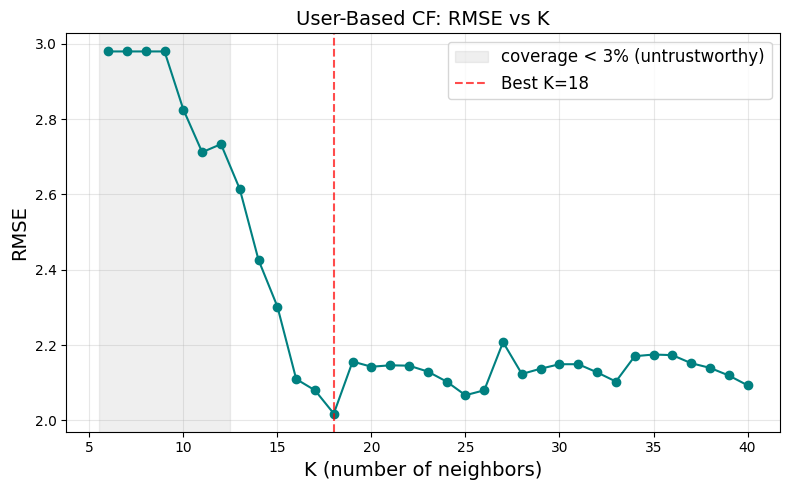

Optimal K=18 with RMSE=2.0178


In [33]:
# --- Plot RMSE vs K ---
plt.figure(figsize=(8, 5))
plt.plot(list(results_K.keys()), list(results_K.values()), 'o-', color='teal')
_eligible = {K: r for K, r in results_K.items() if not np.isnan(r) and coverage_K[K] >= MIN_COVERAGE}
best_K = min(_eligible, key=_eligible.get) if _eligible else min(results_K, key=results_K.get)
_low = [K for K in results_K if coverage_K[K] < MIN_COVERAGE]
if _low:
    plt.axvspan(min(results_K) - 0.5, max(_low) + 0.5, color='grey', alpha=0.12,
                label=f'coverage < {MIN_COVERAGE:.0%} (untrustworthy)')
plt.axvline(x=best_K, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_K}')
plt.xlabel('K (number of neighbors)', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.title('User-Based CF: RMSE vs K', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal K={best_K} with RMSE={results_K[best_K]:.4f}")

# Hyperparameter Tuning: Optimal n_neighbors for Item-Based CF


In [34]:
print(f"Train item-user matrix: {train_item_user.shape}")

def evaluate_item_K(K, item_user_sp, train_sp, test_df,
                    user_enc_t, isbn_enc_t, isbn_dec_t):
    """
    Evaluate Item-Based CF with a given n_neighbors on the test set.
    
    For each test (user, item) pair:
    - Find the K nearest items to the target item (by cosine on item-user vectors)
    - Among those K neighbors, keep only items the user rated in training
    - Predict: weighted average of the user's training ratings on those neighbors
    """
    knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=K + 1)
    knn.fit(item_user_sp)

    test_valid = test_df[
        test_df['UserID'].isin(user_enc_t) &
        test_df['ISBN'].isin(isbn_enc_t)
    ].copy()
    if test_valid.empty:
        return np.nan

    # Sample up to 200 users (same as User-CF), then use all their test ratings
    sampled_uids = test_valid["UserID"].unique()
    if len(sampled_uids) > 200:
        rng = np.random.RandomState(42)
        sampled_uids = rng.choice(sampled_uids, 200, replace=False)
    test_valid = test_valid[test_valid["UserID"].isin(sampled_uids)]

    errors = []
    for _, row in test_valid.iterrows():
        uid = row['UserID']
        isbn = row['ISBN']
        actual = row['Rating']

        uid_idx = user_enc_t[uid]
        item_idx = isbn_enc_t[isbn]

        user_train_vec = np.asarray(train_sp[uid_idx].todense()).flatten()

        distances, indices = knn.kneighbors(item_user_sp[item_idx])
        neighbor_items = indices.flatten()
        neighbor_dists = distances.flatten()

        weighted_sum = 0.0
        sim_sum = 0.0
        for n_item, dist in zip(neighbor_items, neighbor_dists):
            if n_item == item_idx:
                continue
            sim = 1 - dist
            if sim <= 0:
                continue
            if user_train_vec[n_item] == 0:
                continue
            weighted_sum += sim * user_train_vec[n_item]
            sim_sum += sim

        if sim_sum > 0:
            pred = weighted_sum / sim_sum
            errors.append((pred - actual) ** 2)

    coverage = len(errors) / len(test_valid) if len(test_valid) else 0.0
    if not errors:
        return np.nan, coverage
    return np.sqrt(np.mean(errors)), coverage


# --- Sweep n_neighbors values ---
K_item_values = [i for i in range(5,31)]
results_item_K = {}
coverage_item_K = {}

for K in K_item_values:
    rmse, cov = evaluate_item_K(K, train_item_user, train_sparse, test_ratings,
                                train_user_enc, train_isbn_enc, train_isbn_dec)
    results_item_K[K] = rmse
    coverage_item_K[K] = cov
    print(f"n_neighbors={K:3d}  →  RMSE={rmse:.4f}  coverage={cov*100:4.1f}%")

# Coverage gate (same rationale as User-CF): ignore low-coverage tiny-sample RMSE
MIN_COVERAGE_ITEM = 0.03
_eligible = {K: r for K, r in results_item_K.items() if not np.isnan(r) and coverage_item_K[K] >= MIN_COVERAGE_ITEM}
best_item_K = min(_eligible, key=_eligible.get) if _eligible else min(results_item_K, key=results_item_K.get)
print(f"\nBest n_neighbors (coverage >= {MIN_COVERAGE_ITEM:.0%}): {best_item_K} "
      f"(RMSE={results_item_K[best_item_K]:.4f}, coverage={coverage_item_K[best_item_K]*100:.1f}%)")

Train item-user matrix: (49576, 59163)
n_neighbors=  5  →  RMSE=1.2274  coverage= 5.6%
n_neighbors=  6  →  RMSE=1.2608  coverage= 5.7%
n_neighbors=  7  →  RMSE=1.2014  coverage= 5.9%
n_neighbors=  8  →  RMSE=1.2014  coverage= 5.9%
n_neighbors=  9  →  RMSE=1.1395  coverage= 6.9%
n_neighbors= 10  →  RMSE=1.1395  coverage= 6.9%
n_neighbors= 11  →  RMSE=1.1395  coverage= 6.9%
n_neighbors= 12  →  RMSE=1.0948  coverage= 7.5%
n_neighbors= 13  →  RMSE=1.0810  coverage= 7.7%
n_neighbors= 14  →  RMSE=1.0677  coverage= 7.9%
n_neighbors= 15  →  RMSE=1.0662  coverage= 8.0%
n_neighbors= 16  →  RMSE=1.4043  coverage= 8.6%
n_neighbors= 17  →  RMSE=1.3967  coverage= 8.8%
n_neighbors= 18  →  RMSE=1.3749  coverage= 9.2%
n_neighbors= 19  →  RMSE=1.3553  coverage= 9.4%
n_neighbors= 20  →  RMSE=1.3553  coverage= 9.4%
n_neighbors= 21  →  RMSE=1.3553  coverage= 9.4%
n_neighbors= 22  →  RMSE=1.4072  coverage= 9.6%
n_neighbors= 23  →  RMSE=1.4072  coverage= 9.6%
n_neighbors= 24  →  RMSE=1.4003  coverage= 9.8%
n

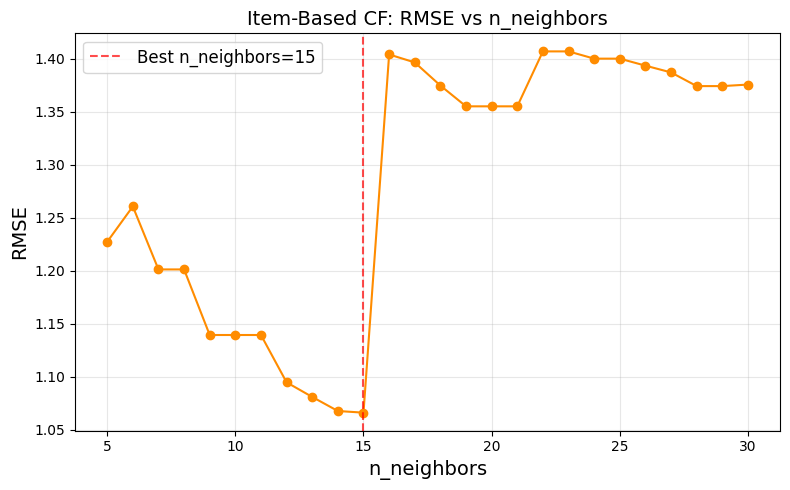

Optimal n_neighbors=15 with RMSE=1.0662


In [35]:
# --- Plot RMSE vs n_neighbors for Item-Based CF ---
plt.figure(figsize=(8, 5))
plt.plot(list(results_item_K.keys()), list(results_item_K.values()), 'o-', color='darkorange')
_eligible = {K: r for K, r in results_item_K.items() if not np.isnan(r) and coverage_item_K[K] >= MIN_COVERAGE_ITEM}
best_item_K = min(_eligible, key=_eligible.get) if _eligible else min(results_item_K, key=results_item_K.get)
_low = [K for K in results_item_K if coverage_item_K[K] < MIN_COVERAGE_ITEM]
if _low:
    plt.axvspan(min(results_item_K) - 0.5, max(_low) + 0.5, color='grey', alpha=0.12,
                label=f'coverage < {MIN_COVERAGE_ITEM:.0%} (untrustworthy)')
plt.axvline(x=best_item_K, color='red', linestyle='--', alpha=0.7, label=f'Best n_neighbors={best_item_K}')
plt.xlabel('n_neighbors', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.title('Item-Based CF: RMSE vs n_neighbors', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal n_neighbors={best_item_K} with RMSE={results_item_K[best_item_K]:.4f}")

# Method Comparison: RMSE *and* Top-10 Ranking Quality

> **What this is (and isn't).** Our task is **recommendation** (rank good books), not rating prediction. This section evaluates two complementary things on a stratified held-out test set (200 users), using inline reimplementations of each method's signal — **not** the `*_recommend` functions we ship:
> 1. **RMSE (signal-quality sanity check)** — does each method's underlying signal track real ratings at all?
> 2. **Top-10 ranking metrics** — Precision@10 / Recall@10 / NDCG@10 — does each method put *liked* books at the top of the list? This is much closer to what recommendation actually cares about.

Methods are reported in one canonical order everywhere below: **Item-CF → Content (TF-IDF) → SVD → User-CF → LightGBM → Hybrid**.

| Method | Prediction approach (for this check) |
|--------|-------------------|
| Item-CF | Weighted avg of the user's ratings on similar items; mean-fallback |
| Content | Weighted avg of the user's ratings on content-similar items |
| SVD | Reconstruct rating: $\hat{r}(u,i) = \bar{r}_u + (U \Sigma V^T)_{u,i}$ |
| User-CF | KNNWithMeans on similar users; mean-fallback when no neighbour rated $i$ |
| LightGBM | Tree model on SVD factors + light user stats (train-only features) |

### The ranking metrics (top-10 quality)

**This is a per-user, personalised evaluation — NOT title-seeded.** It does not call the `*_recommend` functions; it reuses each method's per-`(user, item)` rating predictor (the `_score_*` functions, cousins of `evaluate_K`) and asks: *can the model rank a user's genuinely-liked books above random ones?*

**The 200 users.** test users who also appear in training (so a profile exists), randomly sampled down to 200 (`RandomState(42)`) for speed.

**"Relevant" is defined by the rating:** a candidate book the user rated **≥ 8** in the held-out test set (a "fan" rating). Those are the positives; everything else in the pool is treated as not-relevant.

**Per user, the procedure is:**
1. **Build a candidate pool** = the user's **relevant** books (held-out, rated ≥ 8) **+ 100 random books they never rated** (distractors).
2. **Score every candidate** = each model predicts *"how much would this user like this book?"* — one number per candidate.
3. **Rank the pool** = sort the candidates by that predicted score (high → low) and take the **top-10**.
4. **Count hits** = how many of the top-10 are the relevant books.

Then average each metric over the 200 users:

- **Precision@10** — of the 10 ranked highest, the fraction that are relevant (liked).
- **Recall@10** — of the user's relevant books, how many made the top 10. More informative when the relevant set is tiny.
- **NDCG@10** — like precision but rewards putting relevant books higher in the 10 (rank-aware). The most informative single ranking metric.

> **Read these *relatively*, not absolutely.** "Unrated = irrelevant" is only an assumption (missing-not-at-random), so the absolute numbers are pessimistic — what matters is which method ranks better than which.

> **Key takeaway from the RMSE numbers**: once the mean-fallback gives every method ~100% coverage, they collapse to **≈1.6 RMSE — the predict-the-user's-mean baseline**. With a median of 1 rating/user, a co-rating bridge exists for only ~5% of held-out pairs, so for the rest every method just predicts the mean. **The data is too sparse for rating prediction to beat a trivial baseline** — which is itself the main quantitative finding, and the reason we frame the problem as item-seeded recommendation and lean on the **ranking** metrics rather than RMSE.


In [32]:
# --- Shared test sample: 200 users, same for all methods ---
test_valid = test_ratings[
    test_ratings['UserID'].isin(train_user_enc) &
    test_ratings['ISBN'].isin(train_isbn_enc)
].copy()
sampled_uids = test_valid['UserID'].unique()
if len(sampled_uids) > 200:
    rng = np.random.RandomState(42)
    sampled_uids = rng.choice(sampled_uids, 200, replace=False)
test_sample = test_valid[test_valid['UserID'].isin(sampled_uids)].reset_index(drop=True)
n_total = len(test_sample)
print(f"Test sample: {n_total} ratings from {len(sampled_uids)} users")

# --- Pre-compute shared structures ---
tr_u_sums = np.asarray(train_sparse.sum(axis=1)).flatten()
tr_u_nnz = np.asarray((train_sparse > 0).sum(axis=1)).flatten().clip(min=1)
tr_u_means = tr_u_sums / tr_u_nnz

r_nz, c_nz = train_sparse.nonzero()
c_data = train_sparse.data.astype(np.float64) - tr_u_means[r_nz]
train_centered = csr_matrix((c_data, (r_nz, c_nz)), shape=train_sparse.shape)

# Store predictions per method: {row_index: (pred, actual)}
preds_icf = {}
preds_content = {}
preds_svd = {}
preds_ucf = {}
preds_lgbm = {}

# ========== METHOD 1: Item-CF (n_neighbors=25) ==========
knn_item = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=25)
knn_item.fit(train_item_user)

icf_fallback = 0
for idx, row in test_sample.iterrows():
    uid_idx = train_user_enc[row['UserID']]
    item_idx = train_isbn_enc[row['ISBN']]
    user_train_vec = np.asarray(train_sparse[uid_idx].todense()).flatten()
    distances, indices = knn_item.kneighbors(train_item_user[item_idx])
    weighted_sum = 0.0
    sim_sum = 0.0
    for n_item, dist in zip(indices.flatten(), distances.flatten()):
        if n_item == item_idx:
            continue
        sim = 1 - dist
        if sim <= 0 or user_train_vec[n_item] == 0:
            continue
        weighted_sum += sim * user_train_vec[n_item]
        sim_sum += sim
    if sim_sum > 0:
        pred = weighted_sum / sim_sum
    else:
        pred = tr_u_means[uid_idx]  # fallback: user's mean rating
        icf_fallback += 1
    preds_icf[idx] = (pred, row['Rating'])
print(f"Item-CF: {len(preds_icf)} predictions ({icf_fallback} via mean-fallback)")

# ========== METHOD 2: Content-Based ==========
for idx, row in test_sample.iterrows():
    uid_idx = train_user_enc[row['UserID']]
    isbn = row['ISBN']
    if isbn not in content_isbn_to_idx:
        continue
    item_content_idx = content_isbn_to_idx[isbn]
    user_train_vec = np.asarray(train_sparse[uid_idx].todense()).flatten()
    rated_items = np.where(user_train_vec > 0)[0]
    if len(rated_items) == 0:
        continue
    target_vec = tfidf_matrix[item_content_idx]
    weighted_sum = 0.0
    sim_sum = 0.0
    for train_item_idx in rated_items:
        train_isbn = train_isbn_dec[train_item_idx]
        if train_isbn not in content_isbn_to_idx:
            continue
        content_idx = content_isbn_to_idx[train_isbn]
        sim = cosine_similarity(target_vec, tfidf_matrix[content_idx]).flatten()[0]
        if sim <= 0:
            continue
        weighted_sum += sim * user_train_vec[train_item_idx]
        sim_sum += sim
    if sim_sum > 0:
        pred = weighted_sum / sim_sum
        preds_content[idx] = (pred, row['Rating'])
print(f"Content: {len(preds_content)} predictions")

# ========== METHOD 3: SVD ==========
from scipy.sparse.linalg import svds as svds_eval
U_t, sigma_t, Vt_t = svds_eval(train_centered.astype(np.float64), k=K_FACTORS)
U_sigma = U_t * sigma_t

for idx, row in test_sample.iterrows():
    uid_idx = train_user_enc[row['UserID']]
    item_idx = train_isbn_enc[row['ISBN']]
    pred = tr_u_means[uid_idx] + U_sigma[uid_idx] @ Vt_t[:, item_idx]
    preds_svd[idx] = (pred, row['Rating'])
print(f"SVD: {len(preds_svd)} predictions")

# ========== METHOD 4: User-CF (K=16) ==========
knn_user = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=16)
knn_user.fit(train_centered)

ucf_fallback = 0
for uid in sampled_uids:
    uid_idx = train_user_enc[uid]
    user_train_vec = np.asarray(train_sparse[uid_idx].todense()).flatten()
    rated_mask = user_train_vec > 0
    if not rated_mask.any():
        continue
    user_mean = user_train_vec[rated_mask].mean()
    user_centered_vec = np.zeros(train_sparse.shape[1])
    user_centered_vec[rated_mask] = user_train_vec[rated_mask] - user_mean
    distances, indices = knn_user.kneighbors(user_centered_vec.reshape(1, -1))
    neighbor_idxs = indices.flatten()
    neighbor_sims = 1 - distances.flatten()

    user_test = test_sample[test_sample['UserID'] == uid]
    for idx, row in user_test.iterrows():
        item_idx = train_isbn_enc.get(row['ISBN'])
        if item_idx is None:
            continue
        weighted_dev = 0.0
        sim_sum = 0.0
        for n_idx, sim in zip(neighbor_idxs, neighbor_sims):
            if sim <= 0:
                continue
            n_vec = np.asarray(train_sparse[n_idx].todense()).flatten()
            if n_vec[item_idx] == 0:
                continue
            n_rated = n_vec > 0
            n_mean = n_vec[n_rated].mean()
            weighted_dev += sim * (n_vec[item_idx] - n_mean)
            sim_sum += sim
        if sim_sum > 0:
            pred = user_mean + weighted_dev / sim_sum
        else:
            pred = user_mean  # fallback: no neighbor rated this item -> user's mean
            ucf_fallback += 1
        preds_ucf[idx] = (pred, row['Rating'])
print(f"User-CF: {len(preds_ucf)} predictions ({ucf_fallback} via mean-fallback)")

# ========== METHOD 5: LightGBM (tuned, TRAIN-ONLY features = no leakage) ==========
_tr_u_cnt = np.asarray((train_sparse > 0).sum(axis=1)).flatten()
U_sigma_tr = U_t * sigma_t
def _lgb_feat_tr(uu, ii):
    uu = np.asarray(uu); ii = np.asarray(ii)
    sp = tr_u_means[uu] + np.einsum('ij,ji->i', U_sigma_tr[uu], Vt_t[:, ii])
    base = np.column_stack([_tr_u_cnt[uu], tr_u_means[uu], sp])
    return np.hstack([base, U_sigma_tr[uu], Vt_t[:, ii].T])

_rut = train_ratings['UserID'].map(train_user_enc).to_numpy()
_rit = train_ratings['ISBN'].map(train_isbn_enc).to_numpy()
_ryt = train_ratings['Rating'].to_numpy().astype(float)
_lgb_params = lgb_best_params if 'lgb_best_params' in globals() else dict(
    n_estimators=400, num_leaves=63, learning_rate=0.05)
lgb_cmp = lgb.LGBMRegressor(objective='regression', subsample_freq=1, n_jobs=-1,
                            random_state=42, verbose=-1, **_lgb_params)
lgb_cmp.fit(_lgb_feat_tr(_rut, _rit), _ryt)
_us = test_sample['UserID'].map(train_user_enc).to_numpy()
_is = test_sample['ISBN'].map(train_isbn_enc).to_numpy()
_pred_te = lgb_cmp.predict(_lgb_feat_tr(_us, _is))
for _k, (_i, _row) in enumerate(test_sample.iterrows()):
    preds_lgbm[_i] = (_pred_te[_k], _row['Rating'])
print(f"LightGBM: {len(preds_lgbm)} predictions")

# ========== RESULTS ==========
def calc_rmse(preds_dict):
    if not preds_dict:
        return np.nan
    errors = [(p - a) ** 2 for p, a in preds_dict.values()]
    return np.sqrt(np.mean(errors))

# Overall RMSE + coverage
all_preds = {'Item-CF': preds_icf, 'Content': preds_content, 'SVD': preds_svd, 'User-CF': preds_ucf, 'LightGBM': preds_lgbm}
print(f"\n{'='*60}")
print(f"  Overall RMSE (each method on its own predictions)")
print(f"{'='*60}")
for name, preds in all_preds.items():
    rmse = calc_rmse(preds)
    coverage = len(preds) / n_total * 100
    print(f"  {name:10s}  RMSE={rmse:.4f}  coverage={coverage:.1f}% ({len(preds)}/{n_total})")

# Fair comparison: intersection of all methods
common_idxs = set(preds_svd) & set(preds_ucf) & set(preds_icf) & set(preds_content) & set(preds_lgbm)
print(f"\n{'='*60}")
print(f"  Fair comparison: RMSE on {len(common_idxs)} shared predictions")
print(f"{'='*60}")
if common_idxs:
    for name, preds in all_preds.items():
        common_preds = {k: v for k, v in preds.items() if k in common_idxs}
        rmse = calc_rmse(common_preds)
        print(f"  {name:10s}  RMSE={rmse:.4f}")
else:
    print('  No predictions shared by all 4 methods.')
    # Pairwise: show largest intersection
    import itertools
    names = list(all_preds.keys())
    for a, b in itertools.combinations(names, 2):
        shared = set(all_preds[a]) & set(all_preds[b])
        if shared:
            rmse_a = calc_rmse({k: v for k, v in all_preds[a].items() if k in shared})
            rmse_b = calc_rmse({k: v for k, v in all_preds[b].items() if k in shared})
            print(f"  {a} vs {b}: {len(shared)} shared → {a}={rmse_a:.4f}, {b}={rmse_b:.4f}")

# ========== METHOD 6: Hybrid (weighted blend) ==========
# For each test rating, blend predictions from whichever methods could predict,
# using the same weights as hybrid_recommend: svd=0.2, user=0.3, item=0.3, content=0.2
w = {'icf': 0.15, 'content': 0.28, 'svd': 0.22, 'ucf': 0.15, 'lgbm': 0.20}

preds_hybrid = {}
for idx in range(n_total):
    weighted_pred = 0.0
    weight_sum = 0.0
    if idx in preds_icf:
        weighted_pred += w['icf'] * preds_icf[idx][0]
        weight_sum += w['icf']
    if idx in preds_content:
        weighted_pred += w['content'] * preds_content[idx][0]
        weight_sum += w['content']
    if idx in preds_svd:
        weighted_pred += w['svd'] * preds_svd[idx][0]
        weight_sum += w['svd']
    if idx in preds_ucf:
        weighted_pred += w['ucf'] * preds_ucf[idx][0]
        weight_sum += w['ucf']
    if idx in preds_lgbm:
        weighted_pred += w['lgbm'] * preds_lgbm[idx][0]
        weight_sum += w['lgbm']
    if weight_sum > 0:
        pred = weighted_pred / weight_sum
        actual = test_sample.iloc[idx]['Rating']
        preds_hybrid[idx] = (pred, actual)

all_preds['Hybrid'] = preds_hybrid
rmse_hybrid = calc_rmse(preds_hybrid)
cov_hybrid = len(preds_hybrid) / n_total * 100
print(f"Hybrid: {len(preds_hybrid)} predictions")
print(f"\n{'='*60}")
print(f"  Final Summary (including Hybrid)")
print(f"{'='*60}")
for name, preds in all_preds.items():
    rmse = calc_rmse(preds)
    cov = len(preds) / n_total * 100
    print(f"  {name:10s}  RMSE={rmse:.4f}  coverage={cov:.1f}% ({len(preds)}/{n_total})")


Test sample: 522 ratings from 200 users
Item-CF: 522 predictions (471 via mean-fallback)
Content: 496 predictions
SVD: 522 predictions
User-CF: 522 predictions (502 via mean-fallback)
LightGBM: 522 predictions

  Overall RMSE (each method on its own predictions)
  Item-CF     RMSE=1.6816  coverage=100.0% (522/522)
  Content     RMSE=1.7602  coverage=95.0% (496/522)
  SVD         RMSE=1.6728  coverage=100.0% (522/522)
  User-CF     RMSE=1.6688  coverage=100.0% (522/522)
  LightGBM    RMSE=1.7187  coverage=100.0% (522/522)

  Fair comparison: RMSE on 496 shared predictions
  Item-CF     RMSE=1.7036
  Content     RMSE=1.7602
  SVD         RMSE=1.6945
  User-CF     RMSE=1.6888
  LightGBM    RMSE=1.7343
Hybrid: 522 predictions

  Final Summary (including Hybrid)
  Item-CF     RMSE=1.6816  coverage=100.0% (522/522)
  Content     RMSE=1.7602  coverage=95.0% (496/522)
  SVD         RMSE=1.6728  coverage=100.0% (522/522)
  User-CF     RMSE=1.6688  coverage=100.0% (522/522)
  LightGBM    RMSE=1.

In [33]:
# ============================================================================
#  Ranking-quality evaluation: Precision@10, Recall@10, NDCG@10
# ----------------------------------------------------------------------------
#  The RMSE comparison above measures rating-PREDICTION accuracy (can a model
#  reproduce a hidden rating?). It does NOT tell us whether the TOP-N list is
#  any good -- a model can have great RMSE and mediocre recommendations. These
#  three rank-aware metrics fill that gap. They reuse the structures fitted in
#  the cell above ("Shared test sample ..."), so RUN THAT CELL FIRST.
#
#  Precision@10 -- of the 10 books recommended, the fraction that are relevant.
#  Recall@10    -- of the user's held-out liked books, how many made the top 10.
#                  More informative when the relevant set is tiny.
#  NDCG@10      -- like precision but rewards putting relevant books higher in
#                  the 10 (rank-aware). The most informative single ranking metric,
#                  slightly more code.
#
#  Protocol (per test user):
#    relevant set = held-out books the user rated >= REL_THRESHOLD ("liked")
#    candidate pool = those relevant books + N_NEG randomly sampled books the
#                     user never rated (assumed irrelevant). Each model scores
#                     the whole pool, we take its top-10, and score the metrics.
#
#  CAVEAT: "unrated = irrelevant" is only an assumption (missing-not-at-random),
#  so absolute values are pessimistic -- trust the RELATIVE ranking of models,
#  not the raw numbers.
# ============================================================================
REL_THRESHOLD = 8      # a book is "relevant" if the user rated it >= 8 (a fan rating)
N_NEG = 100            # sampled negatives per user
TOPK = 10
rng_rank = np.random.RandomState(42)
n_train_items = train_sparse.shape[1]

# --- Per-model scorers: score(uid_idx, cand) -> predicted rating per candidate ---
def _score_svd(uid_idx, cand):
    return tr_u_means[uid_idx] + U_sigma[uid_idx] @ Vt_t[:, cand]

def _score_lgbm(uid_idx, cand):
    return lgb_cmp.predict(_lgb_feat_tr(np.full(len(cand), uid_idx), cand))

def _score_ucf(uid_idx, cand):
    # KNNWithMeans over the user's nearest neighbours (vectorised over candidates)
    user_vec = np.asarray(train_sparse[uid_idx].todense()).flatten()
    rated = user_vec > 0
    if not rated.any():
        return np.full(len(cand), np.nan)
    user_mean = user_vec[rated].mean()
    uc = np.zeros(n_train_items); uc[rated] = user_vec[rated] - user_mean
    dist, idx = knn_user.kneighbors(uc.reshape(1, -1))
    nb, sims = idx.flatten(), 1 - dist.flatten()
    keep = sims > 0
    nb, sims = nb[keep], sims[keep]
    if len(nb) == 0:
        return np.full(len(cand), user_mean)
    R = np.asarray(train_sparse[nb][:, cand].todense())     # (K, C) neighbour ratings
    mask = (R > 0).astype(float)
    dev = (R - tr_u_means[nb][:, None]) * mask              # deviation from neighbour mean
    wdev = sims @ dev                                        # (C,)
    ssum = sims @ mask                                       # (C,)
    return np.where(ssum > 0, user_mean + wdev / np.where(ssum > 0, ssum, 1), user_mean)

def _score_icf(uid_idx, cand):
    user_vec = np.asarray(train_sparse[uid_idx].todense()).flatten()
    dist, idx = knn_item.kneighbors(train_item_user[cand])  # (C, n_neighbors) item neighbours
    out = np.empty(len(cand))
    for c in range(len(cand)):
        wsum = ssum = 0.0
        for j, d in zip(idx[c], dist[c]):
            s = 1 - d
            if j == cand[c] or s <= 0 or user_vec[j] == 0:
                continue
            wsum += s * user_vec[j]; ssum += s
        out[c] = wsum / ssum if ssum > 0 else tr_u_means[uid_idx]
    return out

def _score_content(uid_idx, cand):
    user_vec = np.asarray(train_sparse[uid_idx].todense()).flatten()
    rated = np.where(user_vec > 0)[0]
    rated_rows, rated_ratings = [], []
    for it in rated:
        ci = content_isbn_to_idx.get(train_isbn_dec[it])
        if ci is not None:
            rated_rows.append(ci); rated_ratings.append(user_vec[it])
    out = np.full(len(cand), np.nan)
    if not rated_rows:
        return out
    rated_ratings = np.array(rated_ratings)
    cand_rows, cand_pos = [], []
    for p, it in enumerate(cand):
        ci = content_isbn_to_idx.get(train_isbn_dec[it])
        if ci is not None:
            cand_rows.append(ci); cand_pos.append(p)
    if not cand_rows:
        return out
    S = cosine_similarity(tfidf_matrix[cand_rows], tfidf_matrix[rated_rows])  # (Cc, R)
    denom = S.sum(axis=1)
    out[cand_pos] = np.where(denom > 0, (S @ rated_ratings) / np.where(denom > 0, denom, 1), np.nan)
    return out

scorers = {'Item-CF': _score_icf, 'Content': _score_content, 'SVD': _score_svd,
           'User-CF': _score_ucf, 'LightGBM': _score_lgbm}

# Hybrid uses the same blend weights as the RMSE cell (fallback if not defined)
_w = globals().get('w', {'svd': 0.22, 'ucf': 0.15, 'icf': 0.15, 'content': 0.28, 'lgbm': 0.20})
w_map = {'SVD': _w['svd'], 'User-CF': _w['ucf'], 'Item-CF': _w['icf'],
         'Content': _w['content'], 'LightGBM': _w['lgbm']}

def _ndcg(hits, n_rel, k):
    dcg = sum(h / np.log2(r + 2) for r, h in enumerate(hits[:k]))
    idcg = sum(1 / np.log2(r + 2) for r in range(min(n_rel, k)))
    return dcg / idcg if idcg > 0 else 0.0

metrics = {m: {'P': [], 'R': [], 'N': []} for m in list(scorers) + ['Hybrid']}
n_eval_users = 0

for uid in sampled_uids:
    uid_idx = train_user_enc[uid]
    u_test = test_sample[test_sample['UserID'] == uid]
    pos = [train_isbn_enc[i] for i in u_test[u_test['Rating'] >= REL_THRESHOLD]['ISBN']
           if i in train_isbn_enc]
    pos = list(dict.fromkeys(pos))            # unique, order-preserving
    if not pos:
        continue                              # need >=1 liked held-out book

    # Sample negatives: items the user never rated (in train or test)
    user_vec = np.asarray(train_sparse[uid_idx].todense()).flatten()
    seen = set(np.where(user_vec > 0)[0]) | {train_isbn_enc[i] for i in u_test['ISBN']
                                             if i in train_isbn_enc}
    negs = []
    while len(negs) < N_NEG:
        c = rng_rank.randint(n_train_items)
        if c not in seen:
            negs.append(c); seen.add(c)

    cand = np.array(pos + negs)
    relevant = np.zeros(len(cand), dtype=bool); relevant[:len(pos)] = True
    n_rel = len(pos)
    n_eval_users += 1

    model_scores = {}
    for mname, fn in scorers.items():
        s = fn(uid_idx, cand)
        model_scores[mname] = s
        topk = np.argsort(-np.nan_to_num(s, nan=-np.inf))[:TOPK]
        hits = relevant[topk].astype(float)
        metrics[mname]['P'].append(hits.sum() / TOPK)
        metrics[mname]['R'].append(hits.sum() / n_rel)
        metrics[mname]['N'].append(_ndcg(hits, n_rel, TOPK))

    # Hybrid: weighted average of whichever models could score each candidate
    hyb = np.zeros(len(cand)); wsum = np.zeros(len(cand))
    for mname, s in model_scores.items():
        ok = ~np.isnan(s)
        hyb[ok] += w_map[mname] * s[ok]; wsum[ok] += w_map[mname]
    hyb = np.where(wsum > 0, hyb / np.where(wsum > 0, wsum, 1), -np.inf)
    topk = np.argsort(-hyb)[:TOPK]
    hits = relevant[topk].astype(float)
    metrics['Hybrid']['P'].append(hits.sum() / TOPK)
    metrics['Hybrid']['R'].append(hits.sum() / n_rel)
    metrics['Hybrid']['N'].append(_ndcg(hits, n_rel, TOPK))

print(f"Ranking eval: {n_eval_users} users with >=1 liked held-out book, "
      f"{N_NEG} negatives each, relevant = rating >= {REL_THRESHOLD}\n")
print(f"  {'Model':10s} {'Precision@10':>13s} {'Recall@10':>11s} {'NDCG@10':>9s}")
print("  " + "-" * 46)
for mname in metrics:
    P = np.mean(metrics[mname]['P']); R = np.mean(metrics[mname]['R']); N = np.mean(metrics[mname]['N'])
    print(f"  {mname:10s} {P:13.4f} {R:11.4f} {N:9.4f}")


Ranking eval: 135 users with >=1 liked held-out book, 100 negatives each, relevant = rating >= 8

  Model       Precision@10   Recall@10   NDCG@10
  ----------------------------------------------
  Item-CF           0.1926      0.9642    0.9506
  Content           0.0341      0.2170    0.1730
  SVD               0.0637      0.3587    0.2912
  User-CF           0.1956      0.9592    0.9232
  LightGBM          0.0281      0.1210    0.0862
  Hybrid            0.0333      0.1567    0.1055


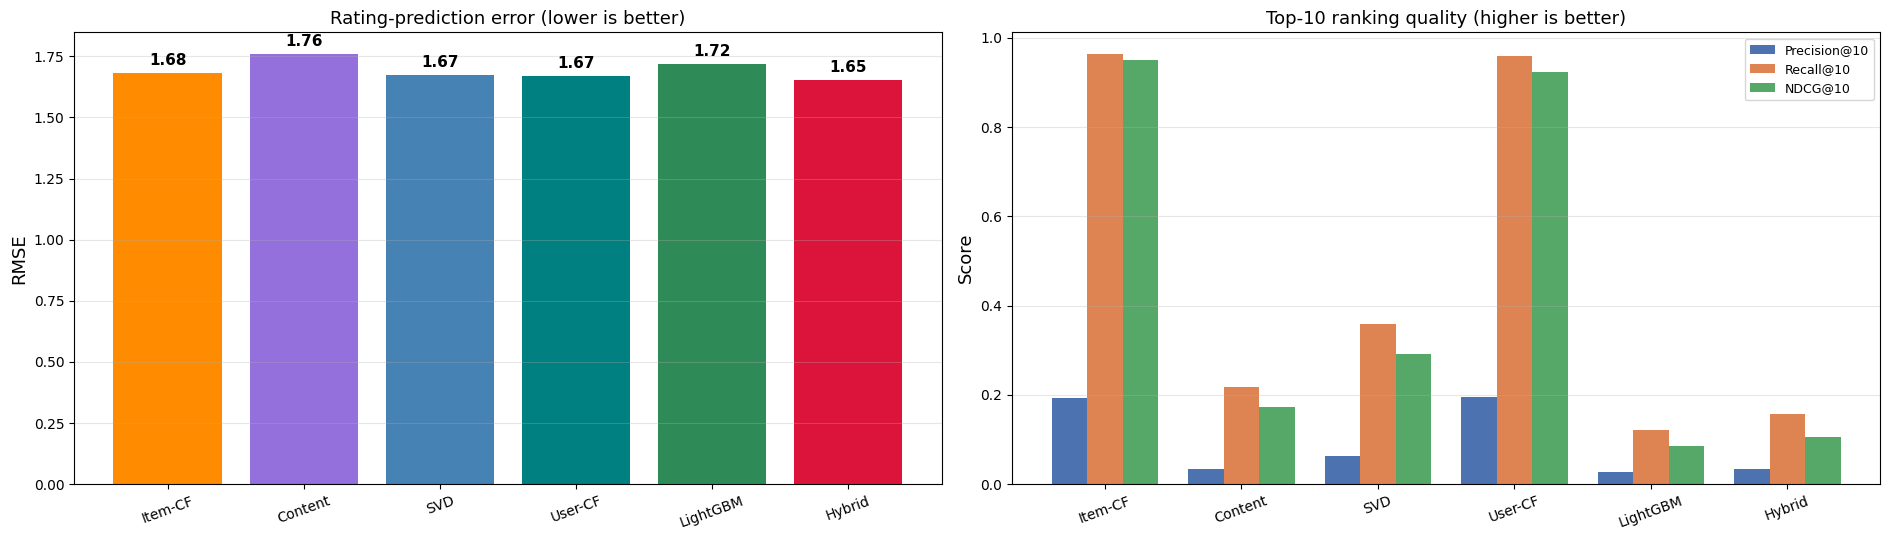

In [34]:
# --- Comparison: RMSE + Coverage + Top-10 ranking quality ---
# Canonical method order (kept identical across every comparison cell):
#   Item-CF, Content (TF-IDF), SVD, User-CF, LightGBM, Hybrid
methods = ['Item-CF', 'Content', 'SVD', 'User-CF', 'LightGBM', 'Hybrid']
all_pred_list = [preds_icf, preds_content, preds_svd, preds_ucf, preds_lgbm, preds_hybrid]
colors = ['darkorange', 'mediumpurple', 'steelblue', 'teal', 'seagreen', 'crimson']
rmses = [calc_rmse(p) for p in all_pred_list]
coverages = [len(p) / n_total * 100 for p in all_pred_list]

# Ranking metrics computed in the cell above (dict `metrics`), pulled in the same order
prec = [np.mean(metrics[m]['P']) for m in methods]
rec  = [np.mean(metrics[m]['R']) for m in methods]
ndcg = [np.mean(metrics[m]['N']) for m in methods]

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(19, 5.5))

# 1) RMSE (rating-prediction error)
bars1 = ax1.bar(methods, rmses, color=colors)
ax1.set_ylabel('RMSE', fontsize=13)
ax1.set_title('Rating-prediction error (lower is better)', fontsize=13)
ax1.grid(axis='y', alpha=0.3); ax1.tick_params(axis='x', rotation=20)
for bar, r in zip(bars1, rmses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{r:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2) Coverage
#bars2 = ax2.bar(methods, coverages, color=colors)
#ax2.set_ylabel('Coverage (%)', fontsize=13)
#ax2.set_title('Prediction coverage (higher is better)', fontsize=13)
#ax2.set_ylim(0, 115); ax2.grid(axis='y', alpha=0.3); ax2.tick_params(axis='x', rotation=20)
#for bar, cov in zip(bars2, coverages):
#    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
#             f'{cov:.0f}%', ha='center', va='bottom', fontsize=10)

# 3) Top-10 ranking quality: Precision@10, Recall@10, NDCG@10 (grouped per method)
x = np.arange(len(methods)); width = 0.26
ax3.bar(x - width, prec, width, label='Precision@10', color='#4C72B0')
ax3.bar(x,         rec,  width, label='Recall@10',    color='#DD8452')
ax3.bar(x + width, ndcg, width, label='NDCG@10',      color='#55A868')
ax3.set_xticks(x); ax3.set_xticklabels(methods, rotation=20)
ax3.set_ylabel('Score', fontsize=13)
ax3.set_title('Top-10 ranking quality (higher is better)', fontsize=13)
ax3.grid(axis='y', alpha=0.3); ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()


# (FOR REFERENCE ONLY)

## EXTRA: LightGBM as a *learned hybrid* (stacker)

Method 6 (RRF) blends the base methods with **fixed** weights; the stacker **learns** the combination. Since our task is **recommendation, not rating prediction**, it is trained to rank *relevant* books on top: label = `liked = rating ≥ 8`, objective = binary classification, ranked by **P(liked)** and judged by **AUC**. Features = the **five** base-method scores per `(user, item)` (incl. LightGBM). RRF stays as the fallback if the stacker doesn't out-rank it.

> **No leakage**: the base scores used as features must come from models that didn't see the label. The runnable cell below reuses the `preds_*` dicts from the Method-Comparison cell (a stack-train / stack-test split); for production, regenerate those base scores **out-of-fold**.

*(Runnable implementation is in the code cell right after the Method Comparison section, since it needs the `preds_*` dicts that cell creates.)*

In [35]:
# Method 6b: LightGBM learned hybrid (stacker) — RUN AFTER the Method Comparison cell above
# (it needs preds_svd / preds_ucf / preds_icf / preds_content / preds_lgbm).
from sklearn.metrics import roc_auc_score

# One row per test pair that ALL four base methods could score
_common = set(preds_svd) & set(preds_ucf) & set(preds_icf) & set(preds_content) & set(preds_lgbm)
X_stack, y_stack = [], []
for _idx in _common:
    X_stack.append([preds_icf[_idx][0], preds_content[_idx][0], preds_svd[_idx][0],
                    preds_ucf[_idx][0], preds_lgbm[_idx][0]])
    y_stack.append(int(preds_svd[_idx][1] >= 8))   # relevance label: did the user LIKE it?
X_stack = np.array(X_stack); y_stack = np.array(y_stack)
print(f"Stacker data: {X_stack.shape[0]} pairs, {y_stack.mean()*100:.0f}% positive (liked)")

if X_stack.shape[0] < 20 or y_stack.min() == y_stack.max():
    print("Not enough labelled data (or single class) to train the stacker on this sample.")
else:
    _rng = np.random.RandomState(0)
    _p = _rng.permutation(len(y_stack)); _c = int(0.7 * len(y_stack))
    _tr, _te = _p[:_c], _p[_c:]

    # Learned hybrid: classify 'liked', then RANK candidates by predicted probability
    stacker = lgb.train(
        dict(objective='binary', metric='auc', learning_rate=0.05,
             num_leaves=15, min_data_in_leaf=20, verbose=-1),
        lgb.Dataset(X_stack[_tr], y_stack[_tr]), num_boost_round=200,
        valid_sets=[lgb.Dataset(X_stack[_te], y_stack[_te])],
        callbacks=[lgb.early_stopping(20, verbose=False)])
    auc_stack = roc_auc_score(y_stack[_te], stacker.predict(X_stack[_te]))

    # Fixed-weight blend (RRF-style) scored on the SAME rows by RANKING ability (AUC)
    _w = np.array([0.15, 0.28, 0.22, 0.15, 0.20])
    auc_blend = roc_auc_score(y_stack[_te], X_stack[_te] @ _w)

    print(f"Stacker AUC={auc_stack:.3f}  vs fixed-weight blend AUC={auc_blend:.3f}")
    print("Feature importances (item, content, svd, user, lgbm):", stacker.feature_importance())

    # Robust fallback gate: deploy the stacker only if it RANKS better than the blend
    use_stacker = auc_stack > auc_blend
    print(f"use_stacker = {use_stacker}  (else fall back to RRF)")

Stacker data: 496 pairs, 63% positive (liked)
Stacker AUC=0.677  vs fixed-weight blend AUC=0.689
Feature importances (item, content, svd, user, lgbm): [47 75 53 30 35]
use_stacker = False  (else fall back to RRF)


## EXTRA: Logistic-regression stacker — *learning the hybrid weights*

The LightGBM stacker (6b) is a nonlinear combiner, so it has **no weights** to read off. A **logistic regression** on the same five base-method scores is linear, so its **coefficients are exactly the weights**. We standardise the scores first (they live on very different scales: svd≈8, item≈1, content≈0.2), fit on the `liked = rating≥8` label, and read the coefficients as the data-driven relative weights — which can be dropped straight into `hybrid_recommend`.

*(Run after the Method Comparison cell, which builds the `preds_*` dicts.)*

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Same five base signals as the LightGBM stacker, but a LINEAR model -> readable weights
_names = ['item', 'content', 'svd', 'user', 'lgbm']
_preds = [preds_icf, preds_content, preds_svd, preds_ucf, preds_lgbm]
_common = set(preds_svd) & set(preds_ucf) & set(preds_icf) & set(preds_content) & set(preds_lgbm)

Xw = np.array([[pd_[i][0] for pd_ in _preds] for i in _common])
yw = np.array([int(preds_svd[i][1] >= 8) for i in _common])
print(f"LR stacker data: {len(yw)} pairs, {yw.mean()*100:.0f}% positive (liked)")

if len(yw) < 20 or yw.min() == yw.max():
    print("Not enough labelled data (or single class) to fit the weight-learner.")
else:
    _rng = np.random.RandomState(0)
    _p = _rng.permutation(len(yw)); _c = int(0.7 * len(yw))
    _tr, _te = _p[:_c], _p[_c:]

    # Standardize so coefficients are comparable across the differently-scaled base scores
    scaler = StandardScaler().fit(Xw[_tr])
    lr = LogisticRegression(max_iter=1000).fit(scaler.transform(Xw[_tr]), yw[_tr])
    auc_lr = roc_auc_score(yw[_te], lr.predict_proba(scaler.transform(Xw[_te]))[:, 1])

    coef = lr.coef_[0]
    print(f"\nLR stacker AUC = {auc_lr:.3f}")
    print("Standardized coefficients (signed relative influence on P(liked)):")
    for n, w in zip(_names, coef):
        print(f"  {n:8s}: {w:+.3f}")

    # Convert to non-negative hybrid weights: clip negatives to 0, normalize to sum 1
    wpos = np.clip(coef, 0, None)
    wpos = wpos if wpos.sum() > 0 else np.abs(coef)
    weights = wpos / wpos.sum()
    print("\nLearned hybrid weights (clip<0 -> normalize):")
    for n, w in zip(_names, weights):
        print(f"  w_{n:8s}= {w:.3f}")
    print("\nDrop straight into the hybrid, e.g.:")
    print(f"  hybrid_recommend(title, w_item={weights[0]:.3f}, w_content={weights[1]:.3f}, "
          f"w_svd={weights[2]:.3f}, w_user={weights[3]:.3f}, w_lgbm={weights[4]:.3f})")

LR stacker data: 496 pairs, 63% positive (liked)

LR stacker AUC = 0.675
Standardized coefficients (signed relative influence on P(liked)):
  item    : +0.980
  content : +0.232
  svd     : -0.717
  user    : +0.972
  lgbm    : -0.102

Learned hybrid weights (clip<0 -> normalize):
  w_item    = 0.449
  w_content = 0.106
  w_svd     = 0.000
  w_user    = 0.445
  w_lgbm    = 0.000

Drop straight into the hybrid, e.g.:
  hybrid_recommend(title, w_item=0.449, w_content=0.106, w_svd=0.000, w_user=0.445, w_lgbm=0.000)


    What the LR Stacker is Saying:

        The LR stacker is trained on a specific dataset: the pairs of (user, item) from your test sample.

        For a given (user, item) pair, its goal is to classify if rating ≥ 8.

        It's trying to find a linear combination of your five base scores to make that classification.

        A negative coefficient for "SVD score" means that, all other variables held constant, a higher predicted SVD score makes it less likely that a user will actually like the book. This is a classic sign of overfitting or a specific correlation in the training data.

    Why Does SVD Have a Negative Weight?

        The SVD model is a collaborative filtering model that predicts a specific rating (e.g., 8.47). The LR stacker is trying to predict a binary "liked" label.

        If the SVD model's predictions are relatively "safe" and don't venture too high or too low, then the data points where it does predict a very high score might be the points where the LR model also has other signals that contradict the SVD prediction.

        In simpler terms, when the SVD model gives a high score, it might be because of a pattern that, in your test set, doesn't actually translate to a "like." The LR model "learns" this pattern and assigns a negative weight to SVD to compensate.

In [37]:
# ============================================================================
#  Choosing hybrid weights by TOP-N ranking quality (NDCG@10), not by proxy
# ----------------------------------------------------------------------------
#  The LR/LightGBM stackers above pick weights via a RATING-PREDICTION proxy
#  (classify "liked" from predicted ratings). But the hybrid we ship RANKS books
#  with RRF, so the only fair judge is a ranking metric on held-out users.
#
#  This cell makes weight selection a contest with ONE judge (NDCG@10) and
#  several contestants:
#     A = current hybrid_recommend defaults
#     B = the LR-learned weights (from the cell above)
#     C = weights found by directly maximising NDCG@10
#     (+ an equal-weight baseline for reference)
#
#  HOW: we reuse the ranking harness (run the "Ranking-quality" cell first).
#  For each user we cache the candidate pool's per-method RRF contributions
#  1/(K_RRF+rank) -- these DON'T depend on the weights, so scoring any weight
#  vector is then just a weighted sum + re-rank (fast). RRF here mirrors
#  hybrid_recommend, so the winning weights drop straight into it.
#
#  CAVEAT: ranks are computed within the 100-negative pool, not the full
#  catalogue, so treat this as a RELATIVE weight comparison, then confirm the
#  winner by eyeballing top-10 lists for a couple of familiar seeds.
# ============================================================================
import inspect
K_RRF = 60                      # same rank-fusion constant as hybrid_recommend
METHOD_KEYS = ['Item-CF', 'Content', 'SVD', 'User-CF', 'LightGBM']

# --- Cache per-user pools as RRF contributions (the expensive part, done once) ---
rng_w = np.random.RandomState(123)
eval_cache = []                 # list of (relevant_mask, {method: rrf_contribution_array})
for uid in sampled_uids:
    uid_idx = train_user_enc[uid]
    u_test = test_sample[test_sample['UserID'] == uid]
    pos = [train_isbn_enc[i] for i in u_test[u_test['Rating'] >= REL_THRESHOLD]['ISBN']
           if i in train_isbn_enc]
    pos = list(dict.fromkeys(pos))
    if not pos:
        continue
    user_vec = np.asarray(train_sparse[uid_idx].todense()).flatten()
    seen = set(np.where(user_vec > 0)[0]) | {train_isbn_enc[i] for i in u_test['ISBN']
                                             if i in train_isbn_enc}
    negs = []
    while len(negs) < N_NEG:
        c = rng_w.randint(n_train_items)
        if c not in seen:
            negs.append(c); seen.add(c)
    cand = np.array(pos + negs)
    relevant = np.zeros(len(cand), dtype=bool); relevant[:len(pos)] = True
    rrf = {}
    for m, fn in scorers.items():
        s = fn(uid_idx, cand)
        order = np.argsort(-np.nan_to_num(s, nan=-np.inf))   # best score -> rank 0
        ranks = np.empty(len(cand)); ranks[order] = np.arange(len(cand))
        rrf[m] = 1.0 / (K_RRF + ranks)
    eval_cache.append((relevant, rrf))
print(f"Cached {len(eval_cache)} users for weight scoring (RRF, K={K_RRF})")

# --- The judge: weight vector -> (NDCG@10, Recall@10, Precision@10) ---
def score_weights(wd):
    Ps, Rs, Ns = [], [], []
    for relevant, rrf in eval_cache:
        fused = sum(wd.get(m, 0.0) * arr for m, arr in rrf.items())
        topk = np.argsort(-fused)[:TOPK]
        hits = relevant[topk].astype(float)
        n_rel = int(relevant.sum())
        Ps.append(hits.sum() / TOPK)
        Rs.append(hits.sum() / n_rel)
        Ns.append(_ndcg(hits, n_rel, TOPK))
    return np.mean(Ns), np.mean(Rs), np.mean(Ps)

def _norm(wd):   # normalise to sum 1 for display (ranking is scale-invariant)
    tot = sum(wd.values()) or 1.0
    return {k: v / tot for k, v in wd.items()}

# --- Contestant A: current hybrid_recommend defaults (read straight off the function) ---
_sig = inspect.signature(hybrid_recommend).parameters
A = {'Item-CF': _sig['w_item'].default, 'Content': _sig['w_content'].default,
     'SVD': _sig['w_svd'].default, 'User-CF': _sig['w_user'].default,
     'LightGBM': _sig['w_lgbm'].default}

# --- Contestant B: LR-learned weights (from the LR stacker cell, if it ran) ---
B = None
if 'weights' in globals() and '_names' in globals() and len(globals()['weights']) == 5:
    _short2key = {'item': 'Item-CF', 'content': 'Content', 'svd': 'SVD',
                  'user': 'User-CF', 'lgbm': 'LightGBM'}
    B = {_short2key[n]: float(w) for n, w in zip(_names, weights) if n in _short2key}

# --- Equal-weight baseline ---
EQ = {m: 0.2 for m in METHOD_KEYS}

# --- Contestant C: random simplex search maximising NDCG@10 ---
best_w, best_ndcg = None, -1.0
for _ in range(3000):
    # Draw samples from the Dirichlet distribution, 5 numbers, all >= 0, summing to 1
    v = rng_w.dirichlet(np.ones(len(METHOD_KEYS))) 
    wd = dict(zip(METHOD_KEYS, v))
    ndcg = score_weights(wd)[0]
    if ndcg > best_ndcg:
        best_ndcg, best_w = ndcg, wd
C = best_w

# --- Report ---
contestants = [('Equal (baseline)', EQ), ('A: current hybrid', A)]
if B is not None:
    contestants.append(('B: LR-learned', B))
contestants.append(('C: NDCG-optimised', C))

print(f"\n{'Weight set':20s} {'NDCG@10':>8s} {'Recall@10':>10s} {'Prec@10':>8s}   weights (Item/Content/SVD/User/LGBM)")
print("-" * 110)
for name, wd in contestants:
    ndcg, rec, prec = score_weights(wd)
    wn = _norm(wd)
    wstr = " ".join(f"{wn[m]:.2f}" for m in METHOD_KEYS)
    print(f"{name:20s} {ndcg:8.4f} {rec:10.4f} {prec:8.4f}   [{wstr}]")

# Best weights, ready to paste into hybrid_recommend
_cn = _norm(C)
print("\nNDCG-optimised weights -> drop into the hybrid:")
print(f"  hybrid_recommend(title, w_item={_cn['Item-CF']:.3f}, w_content={_cn['Content']:.3f}, "
      f"w_svd={_cn['SVD']:.3f}, w_user={_cn['User-CF']:.3f}, w_lgbm={_cn['LightGBM']:.3f})")


Cached 135 users for weight scoring (RRF, K=60)

Weight set            NDCG@10  Recall@10  Prec@10   weights (Item/Content/SVD/User/LGBM)
--------------------------------------------------------------------------------------------------------------
Equal (baseline)       0.4911     0.6570   0.1311   [0.20 0.20 0.20 0.20 0.20]
A: current hybrid      0.3164     0.4563   0.0844   [0.10 0.33 0.22 0.10 0.25]
B: LR-learned          0.8909     0.9399   0.1911   [0.45 0.11 0.00 0.45 0.00]
C: NDCG-optimised      0.9293     0.9620   0.1889   [0.83 0.02 0.04 0.10 0.01]

NDCG-optimised weights -> drop into the hybrid:
  hybrid_recommend(title, w_item=0.833, w_content=0.016, w_svd=0.044, w_user=0.097, w_lgbm=0.011)


# For reference: this is a proof-of-concept, but it overfits to the NDCG metric and is not used in the final system.

## Serving the hybrid from a saved model — `hybrid_model.py`

Everything `hybrid_recommend` needs is packaged in **`hybrid_model.py`**. On import it:
1. loads the saved artifacts (`models/lgbm_recommender.pkl`, `models/lgbm_artifacts.joblib`) + data (`cleaned_data/`),
2. rebuilds the cheap structures the 5 base models need (sparse matrices, KNN index, content list) — **no SVD / TF-IDF / LightGBM retraining**,
3. defines all 5 base models + the RRF hybrid + the diversity filter.

It exposes a recommender that returns just **ISBN + Title**:

```python
from hybrid_model import load_recommender
rec = load_recommender()
rec("Lord of the Rings")
```

This module is the seed of the production serving layer — a FastAPI app would simply `import` it and expose `rec(title)` over HTTP (see the architecture write-up).

In [48]:
# Self-contained serving: hybrid_model.py loads the saved model + all 5 base models
# + the RRF hybrid, with NO retraining. Clean ISBN + Title output, no index, no logs.
from hybrid_model import load_recommender

rec = load_recommender()          # loads artifacts once, returns a silent recommend(title) callable
print(rec("Lord of the Rings").to_string(index=False))

      ISBN                                              Title
0618002219                The Hobbit: or There and Back Again
0345357116    Unfinished Tales: The Lost Lore of Middle-earth
0380776162                                 Lord of Scoundrels
0395257301                                   The Silmarillion
0439139597       Harry Potter and the Goblet of Fire (Book 4)
0395071224                                         The Hobbit
043935806X Harry Potter and the Order of the Phoenix (Book 5)
0812563190                  Elvenblood (Halfblood Chronicles)
0812511751               The Elvenbane (Halfblood Chronicles)
0812522400              Lord of the Isles (Lord of the Isles)


In [10]:
# =====================================================================
# Standalone setup to run Method 5 (lightgbm_recommend) in a FRESH kernel.
# Loads the saved data + LGBM artifacts and re-defines the helpers the
# function calls, so you can run the `lightgbm_recommend` def cell and its
# test cell WITHOUT executing the whole notebook top-to-bottom.
# The individual functions for method 1-6 need to be loaded
# =====================================================================
import os, re
import numpy as np
import pandas as pd
import joblib
import lightgbm                                    # needed to unpickle the saved LGBM model
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR  = "cleaned_data"
MODEL_DIR = "models"



# ---- Saved model + inference bundle (everything lightgbm_recommend needs) ----
lgb_model = joblib.load(f"{MODEL_DIR}/lgbm_recommender.pkl")
_A = joblib.load(f"{MODEL_DIR}/lgbm_artifacts.joblib")
U_sigma  = _A["U_sigma"];  Vt = _A["Vt"];  user_means = _A["user_means"];  lgb_u_cnt = _A["lgb_u_cnt"]
user_enc = _A["user_enc"]; isbn_enc = _A["isbn_enc"]; isbn_dec = _A["isbn_dec"]
tfidf_matrix = _A["tfidf_matrix"]; content_isbn_to_idx = _A["content_isbn_to_idx"]
isbn_to_author = _A["isbn_to_author"]

rng_lgb = np.random.RandomState(42)                 # reproducible fan sub-sampling
DEFAULT_LANGUAGES = {"English"}                     # output language scope
N_RECS = 10                                         # default number of recommendations
MIN_REL_CUM_RATING = 7                              # min mean rating (1-10) to appear in results



print("Loaded data + LGBM artifacts. Now run the `lightgbm_recommend` def cell, then call e.g.:")
print('   lightgbm_recommend("Lord of the Rings")')

Loaded data + LGBM artifacts. Now run the `lightgbm_recommend` def cell, then call e.g.:
   lightgbm_recommend("Lord of the Rings")
